# Optional Project - Transformer Scaling Laws on SVGs

Vincent Hepola - vh2308


# 0. Imports


In [1]:
from IPython.display import SVG, display, Image
import matplotlib.pyplot as plt

import os

# Replace '/path/to/new/cache' with your desired directory
os.environ["HF_HOME"] = "./.cache"
print(os.environ["HF_HOME"])

from datasets import load_dataset, concatenate_datasets, DatasetDict, Value

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)


from torch.optim import AdamW
from pl_bolts.optimizers.lr_scheduler import LinearWarmupCosineAnnealingLR

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

from lxml import etree
import cairosvg

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from scipy.optimize import curve_fit


import re
import time

import mup
from mup import MuReadout, make_base_shapes, set_base_shapes, MuSGD, MuAdam


IBMblue = "#648FFF"
IBMpurple = "#785EF0"
IBMhotpink = "#DC267F"
IBMorange = "#FE6100"
IBMyellow = "#FFB000"

./.cache


/opt/miniconda3/envs/ML/lib/python3.13/site-packages/pl_bolts/__init__.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
/opt/miniconda3/envs/ML/lib/python3.13/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/opt/miniconda3/envs/ML/lib/python3.13/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readt

# 1. Data Collecting and Preprocessing


## 1.1 Datasets


In [2]:
dataset_3 = load_dataset("starvector/svg-stack-simple")
dataset_3 = dataset_3.cast_column("Filename", Value("string"))

# Combine all splits using a dictionary comprehension
combined_dataset = DatasetDict(
    {
        split: concatenate_datasets(
            # [dataset_1[split], dataset_2[split], dataset_3[split]]
            [dataset_3[split]]
        )
        # for split in dataset_1.keys()
        for split in dataset_3.keys()
    }
)

total_items = 300000

dataset = combined_dataset["train"].select(range(total_items))


print(dataset)

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 300000
})


In [3]:
# print(dataset["Svg"][stop_2+3])

In [4]:
# temp = dataset
# temp = temp.map(lambda x: {"str_length": len(x["Svg"])})
# temp['str_length']

In [5]:

# # 2. Convert to pandas
# df = temp.to_pandas()

In [6]:
# df = df[df["str_length"]<TOKEN_THRESHOLD]

In [7]:
# df['str_length'].value_counts()

In [8]:
# plt.hist(df['str_length'].value_counts()*100,bins=20)
# plt.xlabel("Length of string")
# plt.ylabel("Frequency of length")

## 1.2 Normalizing/Cleaning

- Strip comments, metadata, and unnecessary whitespace
- Normalize coordinate precision (e.g., round to 1 decimal place) to reduce vocabulary
- Optionally canonicalize attribute ordering
- Remove SVGs that are too short (< 50 characters) or too long (above your chosen token threshold)
- Validate that all SVGs in the cleaned set parse as valid XML
- Ensure all SVGs render without errors (use lxml for XML parsing, optionally CairoSVG for render validation)


In [9]:
def clean_svg(svg_text):
    # 1. Remove XML comments
    svg_text = re.sub(r"", "", svg_text, flags=re.DOTALL)

    # 2. Function to clean ONLY the path data string
    def clean_path_data(match):
        path_string = match.group(1)

        # Space out the letters (M, L, C, Z, etc.)
        path_string = re.sub(r"([a-zA-Z])", r" \1 ", path_string)

        # Replace commas with spaces
        path_string = path_string.replace(",", " ")

        # Round numbers to 1 decimal place
        def round_match(m):
            try:
                return f"{float(m.group(0)):.1f}"
            except ValueError:
                return m.group(0)

        path_string = re.sub(r"-?\d*\.?\d+", round_match, path_string)

        # Clean up any messy double-spaces inside the quotes
        path_string = re.sub(r"\s+", " ", path_string).strip()

        # Return it wrapped back in d="..."
        return f'd="{path_string}"'

    # 3. Apply the cleaner ONLY to the d="..." attributes
    svg_text = re.sub(r'd="([^"]+)"', clean_path_data, svg_text)

    # 4. Clean up any overall messy whitespace
    svg_text = re.sub(r"\s+", " ", svg_text).strip()

    return svg_text

In [10]:
import re


def post_process_svg(svg_string):
    """Cleans up spaces injected by the tokenizer and closes truncated tags."""

    # 1. Fix basic brackets and slashes
    svg_string = re.sub(r"<\s+", "<", svg_string)
    svg_string = re.sub(r"\s+>", ">", svg_string)
    svg_string = re.sub(r"<\s*/\s*", "</", svg_string)
    svg_string = re.sub(r"/\s*>", "/>", svg_string)

    # 2. Fix decimals (e.g., 12 . 0 -> 12.0)
    svg_string = re.sub(r"\s*\.\s*", ".", svg_string)

    # 3. Fix equals signs and quotes
    svg_string = re.sub(r"\s*=\s*", "=", svg_string)
    svg_string = svg_string.replace('=" ', '="').replace(' "', '"')

    # 4. Fix hyphens in attribute names (e.g., "stroke - width" -> "stroke-width")
    svg_string = re.sub(r"\s*-\s*", "-", svg_string)

    # 5. Fix colons and slashes in xmlns URLs
    svg_string = re.sub(r"\s*:\s*", ":", svg_string)
    svg_string = svg_string.replace("http:// ", "http://")
    svg_string = svg_string.replace(" / ", "/")

    # --- 6. AUTO-CLOSING TRUNCATED TAGS ---
    # If the generation hit max_new_tokens, it will be cut off mid-string.

    # # Close open quotes
    # if svg_string.count('"') % 2 != 0:
    #     svg_string += '"'

    # # Close open path tags
    # if "<path" in svg_string and not (
    #     "/>" in svg_string.split("<path")[-1] or "</path>" in svg_string
    # ):
    #     svg_string += " />"

    # # Close the root svg tag
    # if "</svg>" not in svg_string:
    #     svg_string += "</svg>"

    # --- 7. ADD WHITE BACKGROUND ---
    # Injects a 100% width/height white rectangle right after the opening <svg ...> tag
    svg_string = re.sub(
        r"(<svg[^>]*>)",
        r'\1<rect width="100%" height="100%" fill="white"/>',
        svg_string,
        count=1,
    )

    return svg_string


def evaluate_and_render(svg_string, filename):
    """Checks XML validity and attempts to render using CairoSVG."""

    # --- CLEAN THE STRING FIRST ---
    svg_string = post_process_svg(svg_string)

    print(f"post_processed: {svg_string}")

    is_valid_xml = False
    is_renderable = False

    try:
        root = etree.fromstring(svg_string.encode("utf-8"))
        if root.tag.endswith("svg"):
            is_valid_xml = True
    except etree.XMLSyntaxError as e:
        pass

    if is_valid_xml:
        try:
            cairosvg.svg2svg(bytestring=svg_string.encode("utf-8"), write_to=f"images/{filename}.svg")
            cairosvg.svg2png(bytestring=svg_string.encode("utf-8"), write_to=f"images/{filename}.png")
            is_renderable = True
            print(f"✅ Rendered successfully: {filename}")
            display(Image(filename=f"{filename}.png"))
        except Exception as e:
            print(f"❌ Valid XML, but CairoSVG failed to render: {e}")
    else:
        print(f"❌ Invalid XML Structure")
        # Optional: print(svg_string) to see exactly where it failed!

    return is_valid_xml, is_renderable

### Clean and verify all svgs in training set


In [11]:
TOKEN_THRESHOLD = 2048

In [12]:
from svg_utils import process_row

In [13]:
print("Cleaning datasets with multiprocessing...")
cleaned_dataset = dataset.map(process_row, num_proc=8)
print("Done!")

remaining_items = len(cleaned_dataset)
print(remaining_items)

Cleaning datasets with multiprocessing...
Done!
300000


In [14]:
stop_1 = int(remaining_items * 0.98)
stop_2 = stop_1 + int(remaining_items * 0.01)
stop_3 = stop_2 + int(remaining_items * 0.01)

cleaned_train = cleaned_dataset.select(range(stop_1))
cleaned_val = cleaned_dataset.select(range(stop_1, stop_2))
cleaned_test = cleaned_dataset.select(range(stop_2, stop_3))

In [15]:
print(cleaned_train.num_rows)
print(cleaned_val.num_rows)
print(cleaned_test.num_rows)

294000
3000
3000


In [16]:
def is_valid(d):
    svg_string = d["Svg"]

    if len(svg_string) <= 50 or len(svg_string) > TOKEN_THRESHOLD:
        return False

    try:
        etree.fromstring(svg_string.encode("utf-8"))
    except etree.XMLSyntaxError:
        return False

    return True


filtered_train = cleaned_train.filter(is_valid)

In [17]:
print(f"filtered_train.num_rows: {filtered_train.num_rows}")

filtered_train.num_rows: 204630


<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M18.990570068359375 7.679737091064453 L22.285717010498047 7.679737091064453 C22.443262100219727 7.846954822540283 22.600805282592773 8.014172554016113 22.758350372314453 8.181390762329102 L22.758350372314453 11.678834915161133 C22.600805282592773 11.846055030822754 22.443262100219727 12.013275146484375 22.285717010498047 12.180495262145996 L18.990570068359375 12.180495262145996 C18.833024978637695 12.013275146484375 18.675479888916016 11.846055030822754 18.517934799194336 11.678834915161133 L18.517934799194336 8.181390762329102 C18.675479888916016 8.014172554016113 18.833024978637695 7.846954822540283 18.990570068359375 7.679737091064453 L18.990570068359375 7.679737091064453"></path>
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M1.942561149597168 7.6803979873657

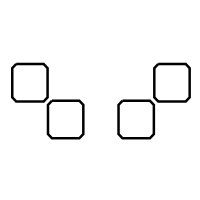

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 19.0 7.7 L 22.3 7.7 C 22.4 7.8 22.6 8.0 22.8 8.2 L 22.8 11.7 C 22.6 11.8 22.4 12.0 22.3 12.2 L 19.0 12.2 C 18.8 12.0 18.7 11.8 18.5 11.7 L 18.5 8.2 C 18.7 8.0 18.8 7.8 19.0 7.7 L 19.0 7.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 1.9 7.7 L 5.2 7.7 C 5.4 7.8 5.6 8.0 5.7 8.2 L 5.7 11.7 C 5.6 11.8 5.4 12.0 5.2 12.2 L 1.9 12.2 C 1.8 12.0 1.6 11.8 1.5 11.7 L 1.5 8.2 C 1.6 8.0 1.8 7.8 1.9 7.7 L 1.9 7.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 6.2 12.1 L 9.5 12.1 C 9.7 12.3 9.8 12.4 10.0 12.6 L 10.0 16.1 C 9.8 16.3 9.7 16.4 9.5 16.6 L 6.2 16.6 C 6.1 16.4 5.9 16.3 5.8 16.1 L 5.8 12.6 C 5.9 12.4 6.1 12.3 6.2 12.1 L 6.2 12.1"></path> <path 

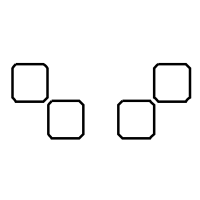

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M14.369558334350586 9.34465217590332 L14.369558334350586 9.34465217590332 C14.664395332336426 11.129638671875 17.73155975341797 11.764588356018066 19.171367645263672 12.745506286621094 L19.50189971923828 13.011774063110352 L19.14943504333496 13.037782669067383 C18.228212356567383 13.262072563171387 21.474658966064453 13.436857223510742 22.115230560302734 13.874602317810059 C22.23280143737793 13.95494556427002 21.83204460144043 13.904967308044434 21.690673828125 13.922056198120117 C21.309267044067383 13.968161582946777 20.917797088623047 13.963937759399414 20.54692268371582 14.06418228149414 C20.170730590820312 14.165863990783691 19.15968894958496 15.140692710876465 19.03168296813965 14.057022094726562 C19.002511978149414 13.810063362121582 19.555959701538086 13.99087905883789 19.740415573120117 13.824099

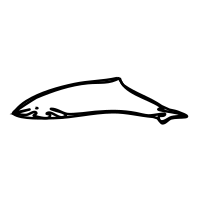

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 14.4 9.3 L 14.4 9.3 C 14.7 11.1 17.7 11.8 19.2 12.7 L 19.5 13.0 L 19.1 13.0 C 18.2 13.3 21.5 13.4 22.1 13.9 C 22.2 14.0 21.8 13.9 21.7 13.9 C 21.3 14.0 20.9 14.0 20.5 14.1 C 20.2 14.2 19.2 15.1 19.0 14.1 C 19.0 13.8 19.6 14.0 19.7 13.8 C 20.2 13.4 18.4 13.9 17.8 13.9 C 17.3 13.8 16.8 13.7 16.3 13.6 C 14.7 13.3 13.1 13.3 11.4 13.4 C 11.4 13.4 8.6 13.8 8.0 13.7 C 7.4 13.5 6.8 13.0 6.1 13.1 C 6.0 13.1 6.3 13.2 6.4 13.2 C 6.9 13.4 7.5 13.4 7.9 13.8 C 8.0 13.9 7.6 14.1 7.4 14.1 C 6.8 14.1 6.1 13.2 5.6 13.6 C 5.5 13.7 6.0 13.7 6.0 13.8 C 6.0 14.5 4.7 14.1 4.1 13.9 C 3.9 13.9 4.5 13.7 4.4 13.5 C 4.1 13.2 3.5 13.8 3.1 13.8 C 2.7 13.8 2.4 13.7 2.0 13.7 L 1.7 13.6 L 2.0 13.5 C 5.5 12.6 2.0 13.6 1.8 13.4 C 1.7 13.4 4.2 11.8 4.4 11.7 C 6.3 10.9 8.4 10.2

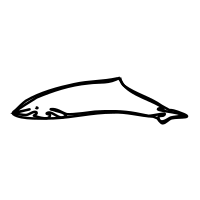

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M12.0 2.5500001907348633 L12.0 2.5500001907348633 C13.606608390808105 2.709066390991211 15.104549407958984 3.060948371887207 16.43461799621582 3.7229955196380615 C17.764686584472656 4.385043144226074 18.926883697509766 5.357255458831787 19.862003326416016 6.756983280181885 C21.186187744140625 8.739078521728516 21.612411499023438 10.979890823364258 21.32829475402832 13.103455543518066 C21.044178009033203 15.227020263671875 20.049724578857422 17.23333740234375 18.532550811767578 18.746442794799805 C17.015378952026367 20.259550094604492 14.975489616394043 21.27944564819336 12.600503921508789 21.430166244506836 C9.992717742919922 21.595661163330078 7.695192337036133 20.690662384033203 5.961532115936279 19.17551040649414 C4.227871894836426 17.660358428955078 3.058077096939087 15.535049438476562 2.705751895904

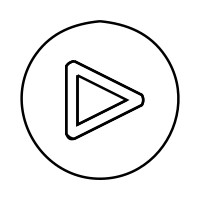

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.0 2.6 L 12.0 2.6 C 13.6 2.7 15.1 3.1 16.4 3.7 C 17.8 4.4 18.9 5.4 19.9 6.8 C 21.2 8.7 21.6 11.0 21.3 13.1 C 21.0 15.2 20.0 17.2 18.5 18.7 C 17.0 20.3 15.0 21.3 12.6 21.4 C 10.0 21.6 7.7 20.7 6.0 19.2 C 4.2 17.7 3.1 15.5 2.7 13.3 C 2.4 11.0 2.8 8.6 4.4 6.4 C 5.3 5.1 6.4 4.2 7.7 3.6 C 9.0 3.0 10.5 2.7 12.0 2.6 L 12.0 2.6"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 8.9 7.3 L 13.0 9.4 L 17.0 11.4 C 17.2 11.7 17.2 12.3 17.0 12.6 L 13.0 14.6 L 8.9 16.7 C 8.3 16.8 8.2 16.6 7.9 16.0 L 7.9 12.0 L 8.0 8.0 C 8.1 7.6 8.5 7.4 8.9 7.3 L 8.9 7.3"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 8.9 7.3 L 13.0 9.4 L 17.0 11.4 C 17.2 11.7 17.2 12.3 17.0 1

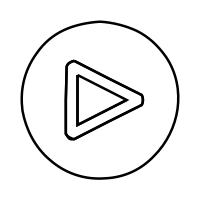

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M7.182300090789795 3.90000057220459 L11.103599548339844 3.90000057220459 L11.103599548339844 9.010200500488281 C11.222024917602539 9.513450622558594 11.119205474853516 10.130194664001465 11.458874702453613 10.519950866699219 C11.810660362243652 10.92361068725586 12.450824737548828 10.923450469970703 12.946800231933594 11.125200271606445 L18.299999237060547 11.125200271606445 L18.299999237060547 17.86349868774414 C18.025169372558594 18.469364166259766 17.443218231201172 18.97343635559082 16.817699432373047 19.200000762939453 L12.0 19.200000762939453 L7.182300090789795 19.200000762939453 C6.556845664978027 18.973257064819336 5.974910736083984 18.469327926635742 5.700000286102295 17.86349868774414 L5.700000286102295 11.57699966430664 L5.700000286102295 5.290500164031982 C5.973606586456299 4.670736789703369 

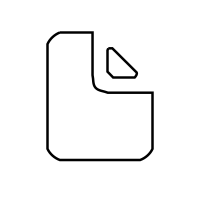

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 7.2 3.9 L 11.1 3.9 L 11.1 9.0 C 11.2 9.5 11.1 10.1 11.5 10.5 C 11.8 10.9 12.5 10.9 12.9 11.1 L 18.3 11.1 L 18.3 17.9 C 18.0 18.5 17.4 19.0 16.8 19.2 L 12.0 19.2 L 7.2 19.2 C 6.6 19.0 6.0 18.5 5.7 17.9 L 5.7 11.6 L 5.7 5.3 C 6.0 4.7 6.6 4.1 7.2 3.9 L 7.2 3.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 13.0 5.8 L 13.0 5.8 C 13.2 5.8 13.3 5.8 13.5 5.8 L 16.4 8.7 C 16.5 8.9 16.3 9.1 16.2 9.3 L 13.6 9.3 C 13.4 9.1 13.1 8.8 12.9 8.6 L 12.9 6.0 C 12.9 6.0 13.0 5.9 13.0 5.8 L 13.0 5.8"></path></svg>
✅ Rendered successfully: dataset_cleaned_4


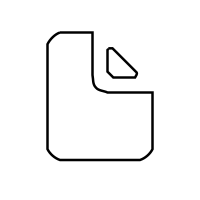

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M11.100000381469727 3.90000057220459 L12.899999618530273 3.90000057220459 L12.899999618530273 8.399999618530273 C13.48355770111084 8.225289344787598 14.044748306274414 7.938466548919678 14.650672912597656 7.8758697509765625 C16.90328598022461 7.643157482147217 19.460105895996094 9.245403289794922 19.611953735351562 11.648396492004395 C19.70379638671875 13.101804733276367 19.25801658630371 14.861464500427246 18.511985778808594 16.489822387695312 C17.765953063964844 18.118181228637695 16.719667434692383 19.615238189697266 15.610494613647461 20.543439865112305 C14.228534698486328 21.699922561645508 13.307929992675781 20.099998474121094 12.0 20.099998474121094 C11.051316261291504 20.099998474121094 10.248680114746094 21.002395629882812 9.300000190734863 21.0 C7.981714248657227 20.996671676635742 6.6684298515

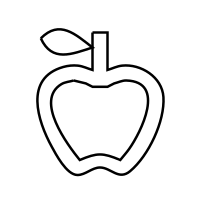

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 11.1 3.9 L 12.9 3.9 L 12.9 8.4 C 13.5 8.2 14.0 7.9 14.7 7.9 C 16.9 7.6 19.5 9.2 19.6 11.6 C 19.7 13.1 19.3 14.9 18.5 16.5 C 17.8 18.1 16.7 19.6 15.6 20.5 C 14.2 21.7 13.3 20.1 12.0 20.1 C 11.1 20.1 10.2 21.0 9.3 21.0 C 8.0 21.0 6.7 18.4 6.2 17.6 C 5.4 16.1 4.5 14.0 4.5 12.2 C 4.5 10.3 5.2 8.7 7.6 8.0 C 8.2 7.9 8.8 7.8 9.3 7.9 C 10.0 7.9 10.5 8.2 11.1 8.4 L 11.1 3.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 4.9 4.6 L 4.9 4.6 C 7.2 2.3 9.0 4.1 11.1 5.7 L 11.1 5.7 C 8.6 6.5 6.2 7.5 4.9 4.6 L 4.9 4.6"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 8.9 9.7 L 8.9 9.7 C 9.3 9.8 9.8 9.9 10.3 10.0 L 11.1 10.4 L 12.9 10.4 L 13.7 10.0 C 14.2 9.9 14

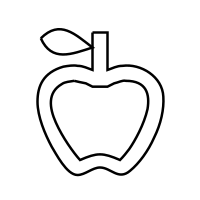

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M17.605199813842773 3.3375003337860107 L17.605199813842773 3.3375003337860107 C18.00119972229004 3.362100124359131 18.397199630737305 3.386699676513672 18.79319953918457 3.411299467086792 L21.488698959350586 6.105900287628174 C21.5132999420166 6.502200126647949 21.537899017333984 6.898500442504883 21.5625 7.294800281524658 L18.10649871826172 11.739001274108887 C18.276464462280273 13.075798034667969 18.437288284301758 13.430655479431152 18.148834228515625 14.76965618133545 C17.58679962158203 17.378620147705078 16.160818099975586 18.82240104675293 14.327781677246094 19.49394989013672 C12.494744300842285 20.165496826171875 10.254651069641113 20.06481170654297 8.064390182495117 19.5848388671875 C5.8741302490234375 19.1048641204834 3.733703851699829 18.245601654052734 2.1000003814697266 17.399999618530273 L2.

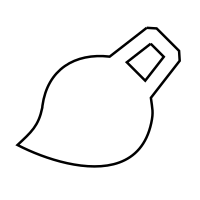

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 17.6 3.3 L 17.6 3.3 C 18.0 3.4 18.4 3.4 18.8 3.4 L 21.5 6.1 C 21.5 6.5 21.5 6.9 21.6 7.3 L 18.1 11.7 C 18.3 13.1 18.4 13.4 18.1 14.8 C 17.6 17.4 16.2 18.8 14.3 19.5 C 12.5 20.2 10.3 20.1 8.1 19.6 C 5.9 19.1 3.7 18.2 2.1 17.4 L 2.1 17.4 C 3.8 15.9 4.6 15.1 5.1 12.9 L 5.1 12.7 C 5.4 10.5 6.4 8.9 7.8 7.9 C 9.2 6.9 11.1 6.6 13.2 6.8 L 17.6 3.3"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 18.1 5.2 L 19.7 6.8 L 17.4 9.7 L 16.4 8.7 C 16.3 8.6 16.3 8.5 16.2 8.5 L 15.2 7.5 L 18.1 5.2"></path></svg>
✅ Rendered successfully: dataset_cleaned_6


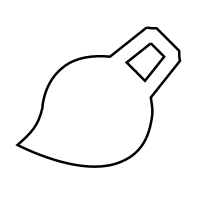

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M28.024810791015625 22.001609802246094 L31.20899200439453 25.185792922973633 L34.39317321777344 28.369976043701172 L31.20899200439453 31.55415916442871 L28.024808883666992 34.73834228515625 L24.840625762939453 31.554157257080078 L21.656444549560547 28.36997413635254"></path>
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M28.024932861328125 22.756196975708008 L28.024932861328125 22.756196975708008 C29.390214920043945 23.699787139892578 30.70892333984375 25.476398468017578 32.21294403076172 26.088516235351562 C32.81950378417969 26.335378646850586 33.503875732421875 26.311647415161133 34.15302276611328 26.398029327392578 C34.74515151977539 26.476823806762695 35.38220977783203 26.358470916748047 35.935401916503906 26.5838623046875 C36.102210998535156 26.6518268585205

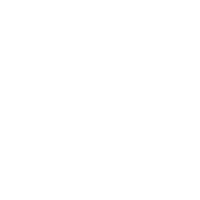

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 28.0 22.0 L 31.2 25.2 L 34.4 28.4 L 31.2 31.6 L 28.0 34.7 L 24.8 31.6 L 21.7 28.4"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 28.0 22.8 L 28.0 22.8 C 29.4 23.7 30.7 25.5 32.2 26.1 C 32.8 26.3 33.5 26.3 34.2 26.4 C 34.7 26.5 35.4 26.4 35.9 26.6 C 36.1 26.7 36.1 27.1 35.9 27.1 C 34.7 27.4 33.4 26.7 32.2 27.1 C 30.9 27.5 30.2 28.9 29.2 29.8 C 28.9 30.1 28.6 30.8 28.2 30.8 C 24.3 30.4 28.5 28.3 28.5 27.5 C 28.5 27.1 28.0 26.8 27.6 26.8 C 27.2 26.8 27.0 27.4 26.7 27.6 C 25.9 28.4 24.4 29.0 24.5 30.2 C 24.5 30.6 25.0 30.8 25.3 31.1 C 26.2 31.9 26.9 33.2 28.0 33.1 C 29.2 33.1 29.9 31.7 30.8 30.9 C 31.9 30.0 34.5 29.0 35.9 29.6 C 36.1 29.7 36.1 30.1 35.9 30.2 C 35.4 30.4 34.7 30.3 34.2 30.3 C 33.

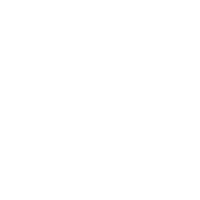

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M3.90000057220459 11.100000381469727 L5.700000286102295 11.100000381469727 L5.700000286102295 12.899999618530273 L3.90000057220459 12.899999618530273 L3.90000057220459 11.100000381469727"></path>
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M11.100000381469727 11.100000381469727 L12.899550437927246 11.100000381469727 L12.899550437927246 12.899550437927246 L11.100000381469727 12.899550437927246 L11.100000381469727 11.100000381469727"></path>
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M18.299999237060547 11.100000381469727 L20.099550247192383 11.100000381469727 L20.099550247192383 12.899550437927246 L18.299999237060547 12.899550437927246 L18.299999237060547 11.100000381469727"></path></svg>
<svg xmlns="http://www.w3.org

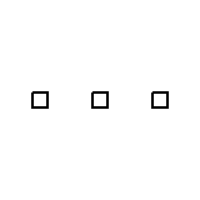

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 11.1 L 5.7 11.1 L 5.7 12.9 L 3.9 12.9 L 3.9 11.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 11.1 11.1 L 12.9 11.1 L 12.9 12.9 L 11.1 12.9 L 11.1 11.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 18.3 11.1 L 20.1 11.1 L 20.1 12.9 L 18.3 12.9 L 18.3 11.1"></path></svg>
✅ Rendered successfully: dataset_cleaned_8


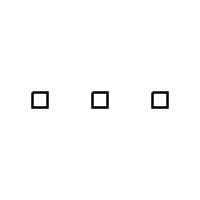

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M5.25 1.2000007629394531 L12.0 1.2000007629394531 L18.75 1.2000007629394531 C21.30148696899414 1.7150592803955078 22.284940719604492 2.6985104084014893 22.799999237060547 5.25 L22.799999237060547 12.0 L22.799999237060547 18.75 C22.284940719604492 21.301488876342773 21.301490783691406 22.284940719604492 18.75 22.799999237060547 L12.0 22.799999237060547 L5.25 22.799999237060547 C2.698509931564331 22.284940719604492 1.7150590419769287 21.301490783691406 1.2000007629394531 18.75 L1.2000007629394531 12.0 L1.2000007629394531 5.25 C1.7150592803955078 2.6985108852386475 2.6985108852386475 1.7150592803955078 5.25 1.2000007629394531 L5.25 1.2000007629394531"></path>
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M12.228899955749512 6.689813137054443 L13.800219535827637 8.13

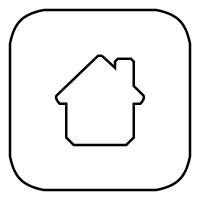

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 5.2 1.2 L 12.0 1.2 L 18.8 1.2 C 21.3 1.7 22.3 2.7 22.8 5.2 L 22.8 12.0 L 22.8 18.8 C 22.3 21.3 21.3 22.3 18.8 22.8 L 12.0 22.8 L 5.2 22.8 C 2.7 22.3 1.7 21.3 1.2 18.8 L 1.2 12.0 L 1.2 5.2 C 1.7 2.7 2.7 1.7 5.2 1.2 L 5.2 1.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.2 6.7 L 13.8 8.1 L 13.8 7.4 C 13.9 7.3 14.0 7.2 14.1 7.1 L 15.7 7.1 C 15.8 7.2 15.9 7.3 16.0 7.4 L 16.0 10.3 L 17.2 11.5 C 17.4 11.8 17.1 12.2 16.8 12.5 L 16.0 12.5 L 16.0 16.5 C 15.7 16.8 15.4 17.1 15.1 17.4 L 8.8 17.4 C 8.5 17.1 8.2 16.8 8.0 16.5 L 8.0 12.4 L 7.2 12.4 C 6.9 12.2 6.6 11.8 6.8 11.5 L 11.8 6.7 C 11.9 6.7 12.1 6.7 12.2 6.7 L 12.2 6.7"></path></svg>
✅ Rendered successfully: dataset_cleaned_9


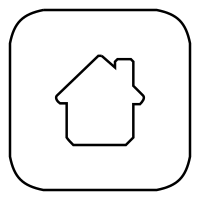

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M16.76507568359375 2.2420310974121094 L16.76507568359375 2.2420310974121094 C17.300701141357422 1.9345310926437378 17.77582550048828 1.48103666305542 18.371952056884766 1.3195310831069946 C20.389278411865234 0.7729867696762085 21.664752960205078 1.6158373355865479 22.223785400390625 2.9162228107452393 C22.782814025878906 4.216608047485352 22.62540054321289 5.9745283126831055 21.776952743530273 7.258123874664307 L17.874608993530273 11.160467147827148 L13.972265243530273 15.062810897827148 L10.069921493530273 18.96515464782715 C8.555950164794922 19.955089569091797 7.876041412353516 20.09019660949707 6.112734317779541 19.690780639648438 L3.3621091842651367 22.44140625 C1.6655669212341309 23.140928268432617 1.5277308225631714 22.5516414642334 1.619765281677246 20.61890411376953 L4.332422256469727 17.90625 C3

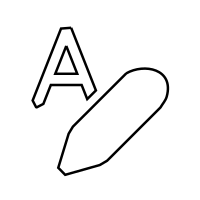

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 8.5 3.3 L 10.0 7.1 L 11.5 10.9 L 10.5 11.9 L 9.8 10.2 L 6.1 10.2 L 5.2 12.5 C 4.9 12.6 4.7 12.7 4.4 12.9 L 4.3 12.8 C 4.2 12.6 4.1 12.3 3.9 12.1 L 5.6 7.7 L 7.3 3.4 C 7.7 3.4 8.1 3.4 8.5 3.3 L 8.5 3.3"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 8.0 5.5 L 9.3 8.9 L 6.6 8.9 L 8.0 5.5"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 15.2 8.8 L 15.2 8.8 C 17.3 7.6 20.9 8.2 20.0 11.6 C 19.9 12.1 19.5 12.5 19.3 12.9 L 16.1 16.1 L 12.9 19.3 C 12.6 19.5 12.3 19.6 12.0 19.8 L 7.8 21.0 C 7.5 20.7 7.3 20.4 7.0 20.1 L 8.2 16.0 C 8.4 15.8 8.6 15.5 8.7 15.2 L 12.0 12.0 L 15.2 8.8"></path></svg>
✅ Rendered successfully: dataset_cleaned_10


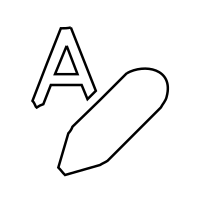

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M11.765833854675293 2.1380958557128906 L11.765833854675293 2.1380958557128906 C12.4210205078125 2.3090991973876953 13.07637882232666 2.552281379699707 13.633452415466309 2.9372243881225586 L13.633452415466309 3.0920019149780273 C13.617701530456543 4.824418544769287 13.540711402893066 6.547464370727539 13.415351867675781 8.264883995056152 C13.28999137878418 9.982303619384766 13.11626148223877 11.694097518920898 12.907028198242188 13.404010772705078 C12.697793960571289 15.113923072814941 12.453058242797852 16.821956634521484 12.185686111450195 18.53185272216797 L12.185686111450195 18.53185272216797 C12.00273609161377 18.527708053588867 11.819900512695312 18.544736862182617 11.637154579162598 18.554332733154297 L11.637154579162598 18.554332733154297 C11.354558944702148 16.835458755493164 11.085570335388184 

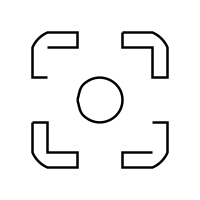

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 14.7 3.9 L 18.3 3.9 C 19.1 4.2 19.8 4.9 20.1 5.7 L 20.1 9.3 L 18.3 9.3 L 18.3 5.7 L 14.7 5.7 L 14.7 3.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 5.7 9.3 L 3.9 9.3 L 3.9 5.7 C 4.2 4.9 4.9 4.2 5.7 3.9 L 9.3 3.9 L 9.3 5.7 L 5.7 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 9.3 12.0 L 9.3 12.0 C 9.6 10.9 9.5 10.3 10.6 9.7 C 12.4 8.7 14.7 9.9 14.7 12.0 C 14.7 14.1 12.4 15.3 10.6 14.3 C 9.5 13.7 9.6 13.1 9.3 12.0 L 9.3 12.0"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 14.7 L 5.7 14.7 L 5.7 18.3 L 9.3 18.3 L 9.3 20.1 L 5.7 20.1 C 4.9 19.8 4.2 19.1 3.9 18.3 L 3.9 14.7"></path> <path

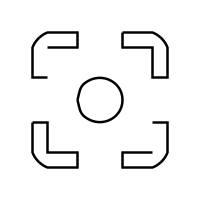

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M925.949951171875 695.0999755859375 L930.6749267578125 695.0999755859375 L935.3999633789062 695.0999755859375 L935.3999633789062 699.824951171875 L935.3999633789062 704.5499877929688 L930.6749267578125 704.5499877929688 L925.949951171875 704.5499877929688 L925.949951171875 699.824951171875 L925.949951171875 695.0999755859375"></path>
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M938.0999755859375 695.0999755859375 L942.824951171875 695.0999755859375 L947.5499877929688 695.0999755859375 L947.5499877929688 699.824951171875 L947.5499877929688 704.5499877929688 L942.824951171875 704.5499877929688 L938.0999755859375 704.5499877929688 L938.0999755859375 699.824951171875 L938.0999755859375 695.0999755859375"></path>
<path fill="none" stroke="black" stroke-width=".3" st

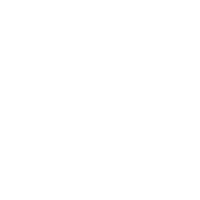

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 925.9 695.1 L 930.7 695.1 L 935.4 695.1 L 935.4 699.8 L 935.4 704.5 L 930.7 704.5 L 925.9 704.5 L 925.9 699.8 L 925.9 695.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 938.1 695.1 L 942.8 695.1 L 947.5 695.1 L 947.5 699.8 L 947.5 704.5 L 942.8 704.5 L 938.1 704.5 L 938.1 699.8 L 938.1 695.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 925.9 707.2 L 930.7 707.2 L 935.4 707.2 L 935.4 712.0 L 935.4 716.7 L 930.7 716.7 L 925.9 716.7 L 925.9 712.0 L 925.9 707.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 938.1 707.2 L 942.8 707.2 L 947.5 707.2 L 947.5 712.0 L 947.5 716.7 L 942.8 716.7 L 9

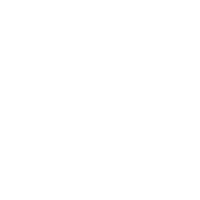

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M12.0 1.585714340209961 L12.0 1.585714340209961 C12.196874618530273 1.7504463195800781 12.393750190734863 1.9151782989501953 12.590624809265137 2.0799102783203125 L15.302678108215332 7.564286231994629 L21.35357093811035 8.444196701049805 C21.687654495239258 8.657639503479004 21.863479614257812 9.209568977355957 21.715179443359375 9.57723331451416 L17.339731216430664 13.844196319580078 L18.376338958740234 19.870981216430664 C18.286148071289062 20.64510154724121 18.171470642089844 20.79791259765625 17.41205406188965 20.57008934020996 L11.999999046325684 17.725444793701172 L6.587945461273193 20.570091247558594 C5.828528881072998 20.797914505004883 5.713849067687988 20.645103454589844 5.623659610748291 19.870983123779297 L6.660266876220703 13.844196319580078 L2.272768020629883 9.577232360839844 C2.1293804645

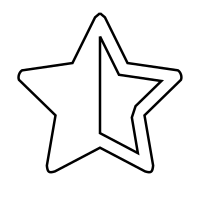

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.0 1.6 L 12.0 1.6 C 12.2 1.8 12.4 1.9 12.6 2.1 L 15.3 7.6 L 21.4 8.4 C 21.7 8.7 21.9 9.2 21.7 9.6 L 17.3 13.8 L 18.4 19.9 C 18.3 20.6 18.2 20.8 17.4 20.6 L 12.0 17.7 L 6.6 20.6 C 5.8 20.8 5.7 20.6 5.6 19.9 L 6.7 13.8 L 2.3 9.6 C 2.1 9.2 2.3 8.7 2.6 8.4 L 8.7 7.6 L 11.4 2.1 C 11.6 1.9 11.8 1.8 12.0 1.6 L 12.0 1.6"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.0 4.4 L 14.3 9.0 L 19.4 9.7 L 16.3 12.7 L 15.8 14.1 L 16.5 18.4 L 12.0 16.0 L 12.0 10.2 L 12.0 4.4"></path></svg>
✅ Rendered successfully: dataset_cleaned_13


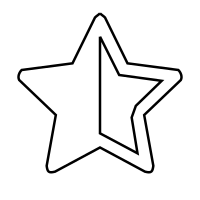

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M6.060000419616699 7.066666603088379 L6.060000419616699 7.066666603088379 C8.70399284362793 7.543519973754883 10.145429611206055 8.798757553100586 12.007200241088867 10.67786693572998 L12.007200241088867 10.67786693572998 C13.592453956604004 9.076515197753906 15.451114654541016 7.005026340484619 17.940000534057617 7.066666603088379 C19.670692443847656 7.109529495239258 21.119369506835938 8.01679801940918 21.9707088470459 9.316153526306152 C22.82204818725586 10.615509033203125 23.076053619384766 12.306952476501465 22.417402267456055 13.91816520690918 C22.17985725402832 14.499258041381836 21.8153018951416 15.039301872253418 21.374740600585938 15.486517906188965 C19.773977279663086 17.111459732055664 18.19379997253418 17.323659896850586 16.67877197265625 16.79149627685547 C15.16374397277832 16.2593345642089

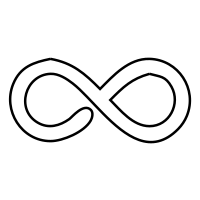

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 6.1 7.1 L 6.1 7.1 C 8.7 7.5 10.1 8.8 12.0 10.7 L 12.0 10.7 C 13.6 9.1 15.5 7.0 17.9 7.1 C 19.7 7.1 21.1 8.0 22.0 9.3 C 22.8 10.6 23.1 12.3 22.4 13.9 C 22.2 14.5 21.8 15.0 21.4 15.5 C 19.8 17.1 18.2 17.3 16.7 16.8 C 15.2 16.3 13.7 15.0 12.4 13.6 C 11.0 12.3 9.8 10.8 8.7 10.0 C 8.0 9.5 7.0 8.8 6.1 8.9 C 4.5 8.9 3.5 10.0 3.1 11.2 C 2.8 12.5 3.2 13.9 4.5 14.7 C 5.8 15.5 7.2 15.1 8.3 14.3 C 8.6 14.1 10.0 12.3 10.9 13.2 C 11.2 13.5 11.1 14.1 10.9 14.5 C 10.1 15.8 7.5 16.9 6.1 16.9 C 4.3 16.9 2.9 16.0 2.0 14.7 C 1.2 13.4 0.9 11.7 1.6 10.1 C 2.4 8.0 4.1 7.5 6.1 7.1 L 6.1 7.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 17.9 8.9 L 17.9 8.9 C 19.2 9.2 19.9 9.1 20.6 10.4 C 21.7 12.4 20.3 15.1 17.9 15

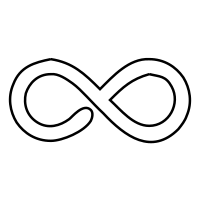

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M6.493911266326904 8.581375122070312 L6.493911266326904 8.581375122070312 C6.557059288024902 8.583199501037598 6.6202073097229 8.585023880004883 6.683355331420898 8.586848258972168 L6.683355331420898 8.586848258972168 C6.425724029541016 9.088022232055664 5.639338493347168 9.011393547058105 5.1186137199401855 9.226787567138672 C3.786586284637451 9.77777099609375 2.898106813430786 11.106379508972168 2.8979506492614746 12.547945022583008 C2.897705554962158 14.809270858764648 4.66041898727417 15.987106323242188 6.43994665145874 16.034290313720703 C8.219473838806152 16.08147430419922 10.015815734863281 14.998007774353027 10.082825660705566 12.736726760864258 L7.627629280090332 12.736726760864258 L7.627629280090332 12.372573852539062 L10.461713790893555 12.548967361450195 C10.092140197753906 14.085835456848145

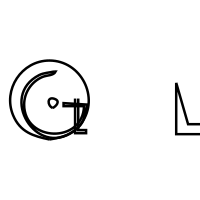

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 6.5 8.6 L 6.5 8.6 C 6.6 8.6 6.6 8.6 6.7 8.6 L 6.7 8.6 C 6.4 9.1 5.6 9.0 5.1 9.2 C 3.8 9.8 2.9 11.1 2.9 12.5 C 2.9 14.8 4.7 16.0 6.4 16.0 C 8.2 16.1 10.0 15.0 10.1 12.7 L 7.6 12.7 L 7.6 12.4 L 10.5 12.5 C 10.1 14.1 10.2 14.7 8.8 15.8 C 6.6 17.4 4.3 16.3 3.2 14.5 C 2.2 12.8 2.2 10.3 4.7 9.0 C 5.2 8.7 5.9 8.7 6.5 8.6 L 6.5 8.6"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 28.7 9.8 L 28.7 9.8 C 29.6 10.0 30.4 10.3 31.1 10.9 L 30.2 11.7 C 29.7 11.4 29.3 11.0 28.8 11.0 C 27.0 10.9 26.5 13.4 27.4 14.5 C 28.1 15.3 29.0 15.0 29.8 14.8 L 29.8 13.8 L 28.7 13.8 L 31.1 12.6 L 31.1 15.6 C 29.8 16.1 28.4 16.6 27.0 15.8 C 25.1 14.8 25.2 11.2 27.1 10.2 C 27.6 9.9 28.2 10.0 28.7 9.8 L 28.7 9.8"></path> <path

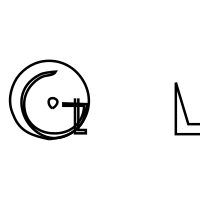

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M11.463464736938477 5.700000286102295 L12.615015029907227 5.700000286102295 C12.877050399780273 5.853915214538574 13.139084815979004 6.0078301429748535 13.40112018585205 6.161745071411133 L13.806389808654785 6.888675212860107 C15.03672981262207 6.9563398361206055 18.753385543823242 6.867768287658691 18.749774932861328 8.865659713745117 L19.52867889404297 9.054659843444824 C20.17723274230957 9.491718292236328 20.69034194946289 10.206108093261719 20.89739990234375 10.960275650024414 L20.648189544677734 13.81764030456543 C20.40826416015625 14.426440238952637 19.97181510925293 14.984434127807617 19.438724517822266 15.363929748535156 L16.247730255126953 16.4578800201416 C14.79981803894043 17.464818954467773 13.954381942749023 18.113475799560547 12.217619895935059 18.299999237060547 L11.78215503692627 18.29999

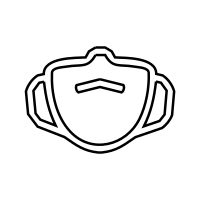

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 11.5 5.7 L 12.6 5.7 C 12.9 5.9 13.1 6.0 13.4 6.2 L 13.8 6.9 C 15.0 7.0 18.8 6.9 18.7 8.9 L 19.5 9.1 C 20.2 9.5 20.7 10.2 20.9 11.0 L 20.6 13.8 C 20.4 14.4 20.0 15.0 19.4 15.4 L 16.2 16.5 C 14.8 17.5 14.0 18.1 12.2 18.3 L 11.8 18.3 C 10.0 18.1 9.2 17.5 7.7 16.5 L 4.5 15.2 C 4.1 14.7 3.8 14.2 3.4 13.7 L 3.1 11.0 C 3.3 10.2 3.9 9.5 4.5 9.1 L 5.3 8.9 C 5.2 6.9 9.0 7.0 10.3 6.9 L 10.7 6.2 C 10.9 6.0 11.2 5.9 11.5 5.7 L 11.5 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 11.5 6.6 L 12.6 6.6 C 13.5 8.2 14.3 7.7 16.0 8.0 C 16.7 8.1 17.8 8.1 17.8 8.8 C 17.9 10.5 17.5 12.6 16.7 14.3 C 15.9 15.9 14.5 16.9 13.0 17.3 C 11.4 17.6 9.7 17.2 8.5 15.8 C 7.6 14.9 7.0 13.8 6.7 12.5 C 6.3 11.3 6.2 10.0 6.2 8

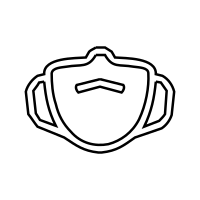

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M7.784573554992676 1.2000007629394531 L11.37971305847168 4.795140743255615 L14.974851608276367 8.390280723571777 L18.569990158081055 11.985420227050781 L14.974852561950684 15.580560684204102 L11.379714965820312 19.175701141357422 L7.784576416015625 22.77083969116211 L5.25 20.23626708984375 L9.366434097290039 16.110843658447266 L13.482867240905762 11.985420227050781 L9.366434097290039 7.859996795654297 L5.25 3.7345733642578125 L7.784573554992676 1.2000007629394531"></path></svg>
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 7.8 1.2 L 11.4 4.8 L 15.0 8.4 L 18.6 12.0 L 15.0 15.6 L 11.4 19.2 L 7.8 22.8 L 5.2 20.2 L 9.4 16.1 L 13.5 12.0 L 9.4 7.9 L 5.2 3.7 L 7.8 1.2"></pa

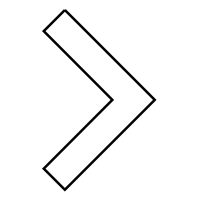

post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 7.8 1.2 L 11.4 4.8 L 15.0 8.4 L 18.6 12.0 L 15.0 15.6 L 11.4 19.2 L 7.8 22.8 L 5.2 20.2 L 9.4 16.1 L 13.5 12.0 L 9.4 7.9 L 5.2 3.7 L 7.8 1.2"></path></svg>
✅ Rendered successfully: dataset_cleaned_17


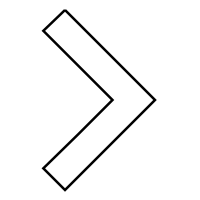

In [18]:
same = 0
diff = 0

for i in range(20):
    
    svg_string_d = dataset["Svg"][i+diff]
    print(svg_string_d)
    
    svg_string_c = cleaned_train["Svg"][i+diff]
    print(svg_string_c)
    
    svg_string_f = filtered_train["Svg"][i]
    print(svg_string_f)
    
    if svg_string_c == svg_string_f:
        same += 1
        
        print(f"{i} same {same}")
        # display(SVG((svg_string_d)))
        # display(SVG((svg_string_c)))
        
        evaluate_and_render(svg_string_d, f"dataset_raw_{same}")
        evaluate_and_render(svg_string_c, f"dataset_cleaned_{same}")
        
    else:
        diff+= 1
        print(f"{i} diff {diff}")
        

## 1.3 Tokenize

Train a BPE tokenizer on your SVG corpus using sentencepiece or the HuggingFace
tokenizers library. Vocabulary sizes in the range 1K–8K are reasonable. Document the vocabulary
size and justify your choice in the report.


In [19]:
# small initials

VOCAB_SIZE = 1000
BLOCK_SIZE = 256

In [20]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [21]:
try:
    tokenizer = Tokenizer.from_file("tokenizer.json")
except:
    print("No tokenizer found in root!")

    tokenizer = Tokenizer(models.BPE())

    tokenizer.pre_tokenizer = pre_tokenizers.Sequence(
        [pre_tokenizers.WhitespaceSplit(), pre_tokenizers.Punctuation()]
    )

    trainer = trainers.BpeTrainer(
        special_tokens=["<|endoftext|>", "<|pad|>"], vocab_size=VOCAB_SIZE
    )

    tokenizer.train_from_iterator(filtered_train["Svg"], trainer)

    tokenizer.save("tokenizer.json")

In [22]:
# sample_2 = filtered_train["Svg"][0]
# sample_2

In [23]:
# # encoded_sample_2 = tokenizer.encode(filtered_train["Svg"][0])

# # print(encoded_sample_2)


# # # # First 10 tokens on encoding
# # for id, token in zip(encoded_sample_2.ids[:100], encoded_sample_2.tokens[:100]):
# #     print(f"{id} -> {token}")
# # dict(sorted(tokenizer.get_vocab().items()))
# dict(sorted(tokenizer.get_vocab().items(), key=lambda item: item[1]))

In [24]:
# tokenizer.decode(encoded_sample_2.ids)

In [25]:
def tokenize_svg(d):

    svg_string = d["Svg"]

    ids = tokenizer.encode(svg_string).ids

    eot_token = tokenizer.token_to_id("<|endoftext|>")

    ids.append(eot_token)

    return {"Filename": d["Filename"], "Svg": d["Svg"], "input_ids": ids}

In [26]:
tokenized_train = filtered_train.map(tokenize_svg)

In [27]:
# tokenized_train["input_ids"]

In [28]:
print("Flattening tokenized_dataset (PyArrow backend)...")

# .data accesses the PyArrow table
# .combine_chunks() ensures the memory is contiguous
# .flatten() removes the sub-lists instantaneously
# .to_numpy() creates a zero-copy NumPy array
train_input_ids = (
    tokenized_train.data["input_ids"].combine_chunks().flatten().to_numpy()
)

print(f"Done! Shape: {train_input_ids.shape}")

Flattening tokenized_dataset (PyArrow backend)...
Done! Shape: (130428077,)


In [29]:
print(f"len(np.unique(train_input_ids)): {len(np.unique(train_input_ids))}")

len(np.unique(train_input_ids)): 940


### Create, clean, filter, and tokenize test/val datasets


In [30]:
print("Preparing val and test dataset")

filtered_test = cleaned_test.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_test = filtered_test.map(tokenize_svg)  # , num_proc=8)
test_input_ids = tokenized_test.data["input_ids"].combine_chunks().flatten().to_numpy()
test_input_ids = np.array(test_input_ids)

filtered_val = cleaned_val.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_val = filtered_val.map(tokenize_svg)  # , num_proc=8)
val_input_ids = tokenized_val.data["input_ids"].combine_chunks().flatten().to_numpy()
val_input_ids = np.array(val_input_ids)

Preparing val and test dataset


In [31]:
tokenized_test

Dataset({
    features: ['Filename', 'Svg', 'input_ids'],
    num_rows: 2066
})

In [32]:
tokenized_val

Dataset({
    features: ['Filename', 'Svg', 'input_ids'],
    num_rows: 2088
})

In [33]:
filtered_train.num_rows + filtered_test.num_rows + filtered_val.num_rows

208784

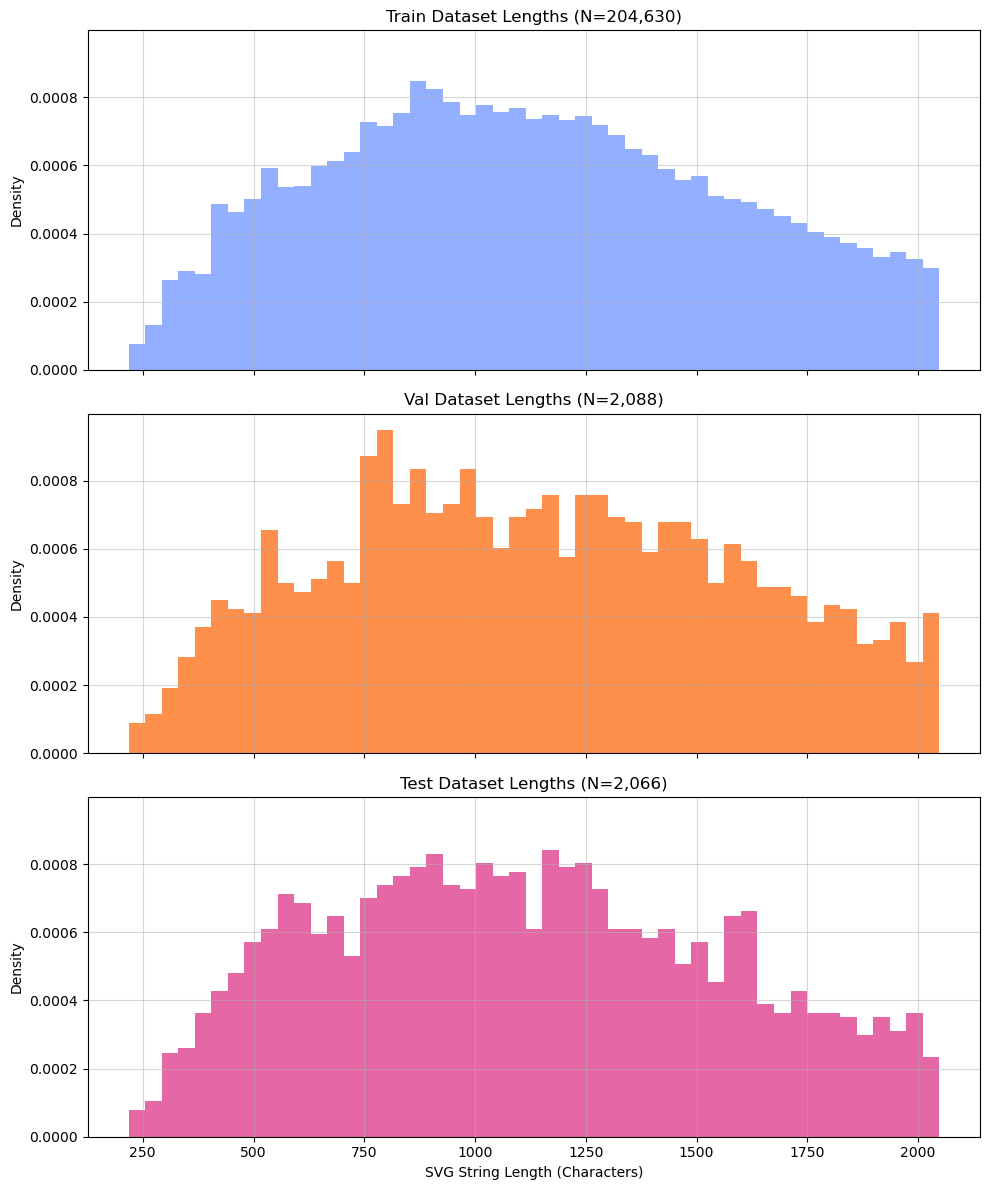

In [34]:
# Extract the lengths without building full DataFrames multiple times
train_lens = pd.DataFrame(tokenized_train)["Svg"].map(len)
val_lens = pd.DataFrame(tokenized_val)["Svg"].map(len)
test_lens = pd.DataFrame(tokenized_test)["Svg"].map(len)

# Create a shared binning strategy so the bars align perfectly on the X-axis
all_lens = pd.concat([train_lens, val_lens, test_lens])
bins = np.linspace(all_lens.min(), all_lens.max(), 50) # 50 bins looks a bit cleaner than 20

# Create 3 vertically stacked subplots that share the X-axis
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True, sharey=True)

data = [
    (train_lens, "Train", IBMblue),
    (val_lens, "Val", IBMorange),
    (test_lens, "Test", IBMhotpink)
]

for ax, (lens, name, color) in zip(axes, data):
    # Using density=True normalizes the Y-axis so you can compare the 
    # distribution shapes despite the massive size difference in splits
    ax.hist(lens, bins=bins, color=color, alpha=0.7, density=True)
    ax.set_title(f"{name} Dataset Lengths (N={len(lens):,})")
    ax.grid(True, alpha=0.5)
    ax.set_ylabel("Density")

plt.xlabel("SVG String Length (Characters)")
plt.tight_layout()
plt.savefig("plots/length_distributions")
plt.show()


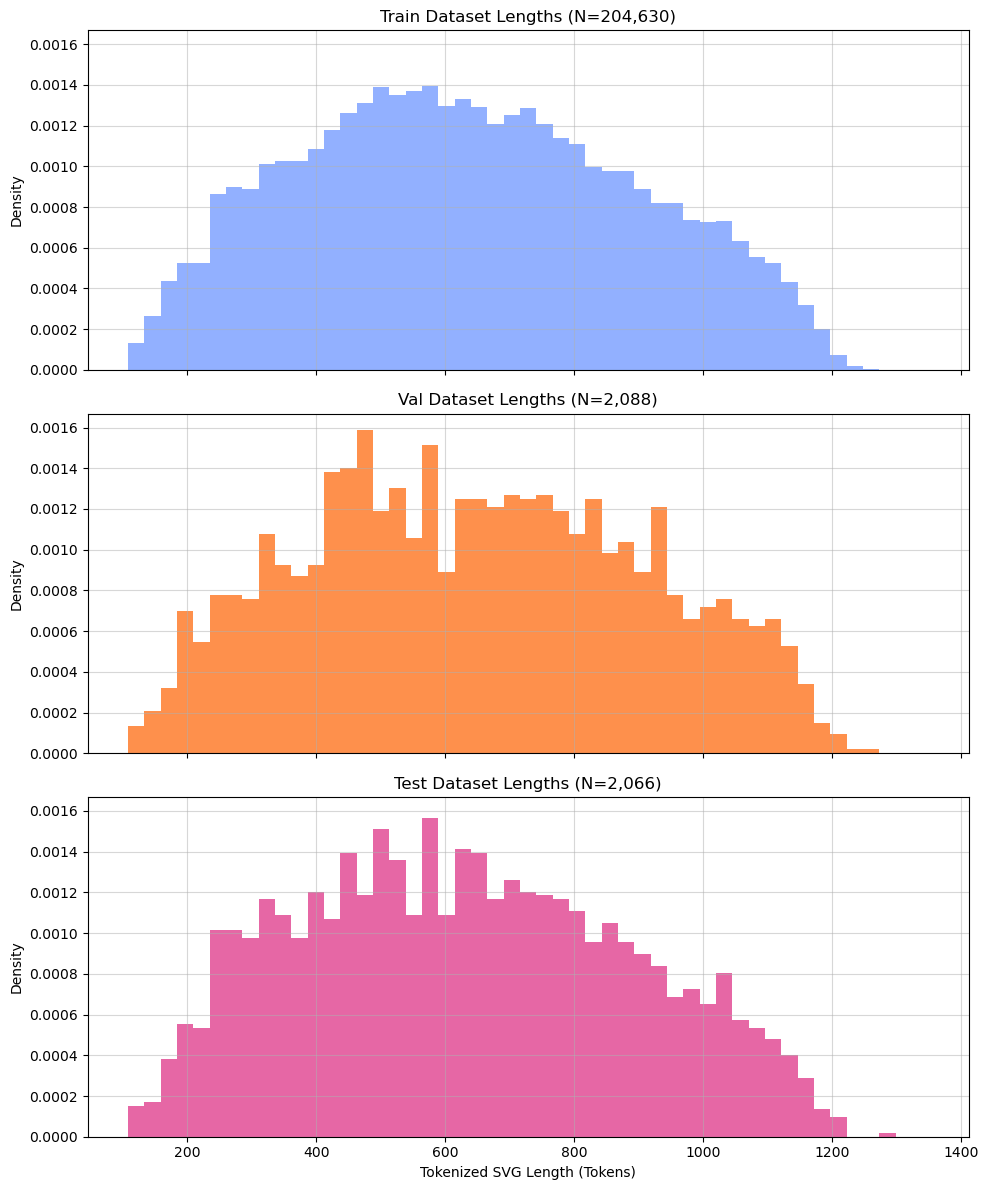

In [35]:
# Extract the lengths without building full DataFrames multiple times
train_lens = pd.DataFrame(tokenized_train)["input_ids"].map(len)
val_lens = pd.DataFrame(tokenized_val)["input_ids"].map(len)
test_lens = pd.DataFrame(tokenized_test)["input_ids"].map(len)

# Create a shared binning strategy so the bars align perfectly on the X-axis
all_lens = pd.concat([train_lens, val_lens, test_lens])
bins = np.linspace(all_lens.min(), all_lens.max(), 50) # 50 bins looks a bit cleaner than 20

# Create 3 vertically stacked subplots that share the X-axis
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True, sharey=True)

data = [
    (train_lens, "Train", IBMblue),
    (val_lens, "Val", IBMorange),
    (test_lens, "Test", IBMhotpink)
]

for ax, (lens, name, color) in zip(axes, data):
    # Using density=True normalizes the Y-axis so you can compare the 
    # distribution shapes despite the massive size difference in splits
    ax.hist(lens, bins=bins, color=color, alpha=0.7, density=True)
    ax.set_title(f"{name} Dataset Lengths (N={len(lens):,})")
    ax.grid(True, alpha=0.5)
    ax.set_ylabel("Density")

plt.xlabel("Tokenized SVG Length (Tokens)")
plt.tight_layout()
plt.savefig("plots/token_length_distributions")
plt.show()


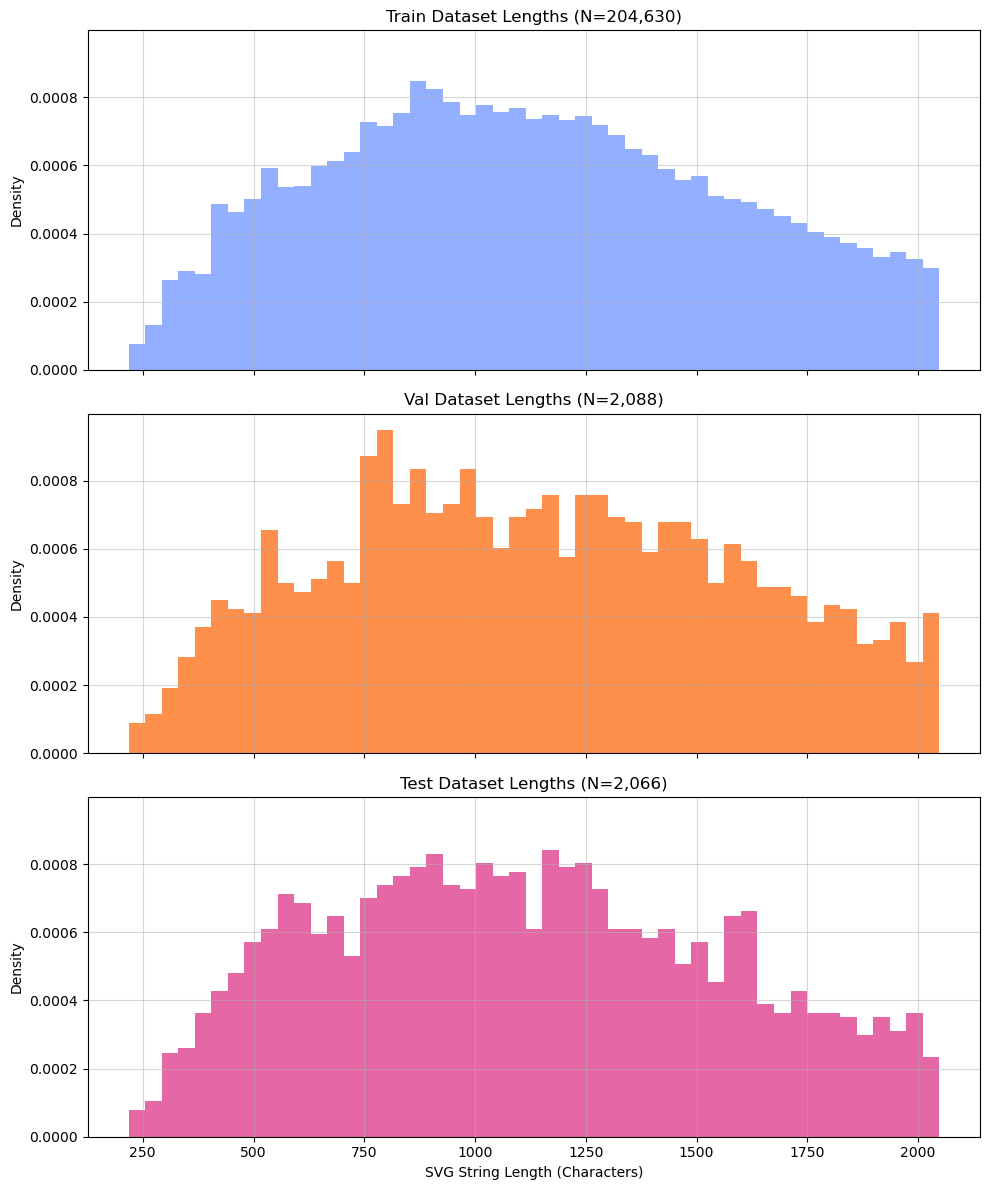

In [36]:
# Extract the lengths without building full DataFrames multiple times
train_lens = pd.DataFrame(filtered_train)["Svg"].map(len)
val_lens = pd.DataFrame(filtered_val)["Svg"].map(len)
test_lens = pd.DataFrame(tokenized_test)["Svg"].map(len)

# Create a shared binning strategy so the bars align perfectly on the X-axis
all_lens = pd.concat([train_lens, val_lens, test_lens])
bins = np.linspace(all_lens.min(), all_lens.max(), 50) # 50 bins looks a bit cleaner than 20

# Create 3 vertically stacked subplots that share the X-axis
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True, sharey=True)

data = [
    (train_lens, "Train", IBMblue),
    (val_lens, "Val", IBMorange),
    (test_lens, "Test", IBMhotpink)
]

for ax, (lens, name, color) in zip(axes, data):
    # Using density=True normalizes the Y-axis so you can compare the 
    # distribution shapes despite the massive size difference in splits
    ax.hist(lens, bins=bins, color=color, alpha=0.7, density=True)
    ax.set_title(f"{name} Dataset Lengths (N={len(lens):,})")
    ax.grid(True, alpha=0.5)
    ax.set_ylabel("Density")

plt.xlabel("SVG String Length (Characters)")
plt.tight_layout()
plt.savefig("plots/length_distributions")
plt.show()


In [37]:
# Check the size of remaining data
all_tokens = np.concat([train_input_ids, val_input_ids, test_input_ids])
print(f"Number of tokens in data: {len(all_tokens)}")
print(
    f"Number of tokens in train: {len(train_input_ids)} -> {(len(train_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in val: {len(val_input_ids)} -> {(len(val_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in test: {len(test_input_ids)} -> {(len(test_input_ids)/len(all_tokens)*100):.2f}%"
)

Number of tokens in data: 133084710
Number of tokens in train: 130428077 -> 98.00%
Number of tokens in val: 1355632 -> 1.02%
Number of tokens in test: 1301001 -> 0.98%


# 2. Transformer Scaling Study

Train a family of decoder-only transformer language models of varying sizes on the SVG data. Measure the
validation loss after 1 epoch of training for each model size.


## 2.0 Setup


### 2.0.0 Dataloaders


In [38]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Convert to 1D tensors
train_data = torch.tensor(train_input_ids, dtype=torch.long)
val_data = torch.tensor(val_input_ids, dtype=torch.long)

# We want sequences of length (BLOCK_SIZE + 1)
# Assuming you still have BLOCK_SIZE = 256 from your earlier cell
seq_len = BLOCK_SIZE + 1


def chunk_data(data, seq_len):
    # Calculate how many full sequences we can make
    num_chunks = len(data) // seq_len

    # Truncate any leftover tokens at the very end that don't fit into a full chunk
    data = data[: num_chunks * seq_len]

    # Reshape the 1D tensor into a 2D grid of shape (num_chunks, seq_len)
    return data.view(num_chunks, seq_len)


# 2. Reshape 1D streams into 2D grids
train_data_2d = chunk_data(train_data, seq_len)
val_data_2d = chunk_data(val_data, seq_len)

# 3. NOW we can slice into X and Y safely!
# X gets everything except the last token of each chunk
X_train = train_data_2d[:, :-1]
# Y gets everything except the first token of each chunk
Y_train = train_data_2d[:, 1:]

X_val = val_data_2d[:, :-1]
Y_val = val_data_2d[:, 1:]

# 4. Bundle into TensorDataset and DataLoader
train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)

train_loader = DataLoader(
    dataset=train_dataset, batch_size=256, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    dataset=val_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True
)

print(f"X Train shape: {X_train.shape}, Y Train shape: {Y_train.shape}")
print(f"X Val shape: {X_val.shape}, Y Val shape: {Y_val.shape}")

X Train shape: torch.Size([507502, 256]), Y Train shape: torch.Size([507502, 256])
X Val shape: torch.Size([5274, 256]), Y Val shape: torch.Size([5274, 256])


### 2.0.1 Define Model and Functions


In [39]:
# Keeping depth the same (n_layers, n_heads) and only varying width (d_model, d_ff)
configs = {
    "Tiny": {"d_model": 128, "n_layers": 6, "n_heads": 6, "d_ff": 512},
    "XL": {"d_model": 768, "n_layers": 6, "n_heads": 6, "d_ff": 3072},
}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 4. Best Model Training and Sample Generation


In Part 2, you tuned the learning rate on the smallest model and used it for all model sizes. In this part,
you will investigate whether µP (Maximal Update Parameterization) can improve scaling behavior by
enabling principled learning rate transfer across model widths. You will also use your scaling laws to make
predictions beyond the model sizes you trained.


## 3.1 Scaling Study


### 3.1.1 Reparameterize


In [40]:
class MuHead(nn.Module):
    """one head of self-attention"""

    def __init__(self, head_size, d_model, block_size):
        super().__init__()
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)

        self.head_size = head_size  # Store this

        # 'tril' is the lower triangular matrix for masking
        # self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape  # Batch, sequence length, embedding dimensionality (d_model)

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # # Compute attention scores
        # wei = q @ k.transpose(-2, -1) * (self.head_size**-1)

        # # Mask out future tokens by replacing 0s in the tril matrix with -infinity
        # wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))

        # output = F.softmax(wei, dim=-1) @ v

        output = F.scaled_dot_product_attention(
            q, k, v, is_causal=True, scale=1.0 / self.head_size
        )

        return output


class MuMultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model, block_size):
        super().__init__()
        head_size = d_model // n_heads
        self.heads = nn.ModuleList(
            [MuHead(head_size, d_model, block_size) for _ in range(n_heads)]
        )

        self.proj = nn.Linear(head_size * n_heads, d_model)

    def forward(self, x):
        x = torch.concat([head(x) for head in self.heads], dim=-1)
        x = self.proj(x)
        return x


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None):
        super().__init__()

        if d_ff == None:
            d_ff = 4 * d_model

        self.layer = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.layer(x)


class MuTransformerBlock(nn.Module):
    def __init__(self, n_heads, d_model, d_ff, block_size):
        super().__init__()

        self.MHA = MuMultiHeadAttention(
            n_heads=n_heads, d_model=d_model, block_size=block_size
        )
        self.ff = FeedForward(d_model=d_model, d_ff=d_ff)
        self.ln_1 = nn.LayerNorm(d_model)
        self.ln_2 = nn.LayerNorm(d_model)

    def forward(self, x):

        x = x + self.MHA(self.ln_1(x))
        x = x + self.ff(self.ln_2(x))

        return x


class MuCustomTransformer(nn.Module):
    """
    n_layers: The total number of identical Transformer blocks stacked on top of each other.
    n_heads: The number of parallel "attention heads" used in the Multi-Head Attention mechanism.
    d_model: The dimensionality of the input and output embeddings, also known as the "hidden size" or "embedding size".
    d_ff: The size of the hidden dimension in the position-wise feed-forward networks (MLP) within each layer.
    """

    def __init__(self, vocab_size, block_size, n_layers, n_heads, d_model, d_ff):
        super().__init__()

        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_ff = d_ff

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_embedding = nn.Embedding(block_size, d_model)

        self.blocks = nn.Sequential(
            *[
                MuTransformerBlock(n_heads, d_model, d_ff, block_size)
                for _ in range(n_layers)
            ]
        )

        self.ln_f = nn.LayerNorm(d_model)
        self.proj = mup.MuReadout(d_model, vocab_size)

    def generate(self, idx, max_new_tokens, temperature=0.8):
        # idx.shape (B,T)

        for _ in range(max_new_tokens):

            # Crop to block_size if too long
            if idx.size(1) <= self.block_size:
                idx_continue = idx
            else:
                idx_continue = idx[:, -self.block_size :]

            # forward into model.
            logits, _ = self(idx_continue)

            # Get the final step logits
            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            # sample randomly from the distribution
            # print(probs.shape)
            idx_next = torch.multinomial(probs, num_samples=1)

            # append the new index to the sequence and continue
            idx = torch.concat((idx, idx_next), dim=1)

        return idx

    def forward(self, idx, targets=None):

        sequence_length = idx.shape[1]

        te = self.token_embedding(idx)

        pe = self.positional_embedding(torch.arange(sequence_length, device=idx.device))

        x = te + pe  # input_embedding

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.proj(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape

            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

In [41]:
name = "XL"  # Explicitly defining the name for your print statements and saving

# Initialize the proxy (Tiny) config
base_model = MuCustomTransformer(
    vocab_size=VOCAB_SIZE, block_size=BLOCK_SIZE, **configs["Tiny"]
).to(device)

# Initialize the model with the specific config
target_model = MuCustomTransformer(
    vocab_size=VOCAB_SIZE, block_size=BLOCK_SIZE, **configs[name]
).to(device)

mup.set_base_shapes(target_model, base_model)

state_dict = torch.load(
    f"mu_model_{name}_best.pt", map_location=device, weights_only=True
)
target_model.load_state_dict(state_dict)

# Set to evaluation mode
target_model.eval()
print("✅ Model loaded successfully!")


params = count_parameters(target_model)
print(f"Parameters: {params:,}")

✅ Model loaded successfully!
Parameters: 44,248,552


# Generate Samples


In [42]:
def generate_svg(
    model, tokenizer, prompt, max_new_tokens=256, temperature=1.0, top_k=None
):
    """Generates SVG text using temperature and Top-K sampling."""
    model.eval()

    # Encode the prompt
    input_ids = tokenizer.encode(prompt).ids
    idx = torch.tensor([input_ids], dtype=torch.long).to(device)
    # new_idx = model.generate(idx, max_new_tokens, temperature=temperature)

    eot_id = tokenizer.token_to_id("<|endoftext|>")

    with torch.inference_mode():
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -model.block_size :]
            logits, _ = model(idx_cond)
            logits = logits[:, -1, :] / temperature

            # Apply Top-K filtering
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("Inf")

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

            if idx_next.item() == eot_id:
                break

    return tokenizer.decode(idx[0].tolist())

## Unconditioned Samples



--- Generating 10 Unconditional Samples ---
Generating Sample 1...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 1 . 2 L 12 . 0 1 . 2 C 14 . 3 1 . 3 16 . 3 2 . 0 17 . 9 3 . 2 C 19 . 5 4 . 4 20 . 8 6 . 1 21 . 8 8 . 2 L 21 . 8 12 . 0 L 21 . 8 15 . 8 C 20 . 9 18 . 7 18 . 9 19 . 7 16 . 2 17 . 9 L 16 . 2 17 . 9 C 15 . 0 19 . 1 14 . 0 19 . 8 12 . 5 20 . 3 L 12 . 0 20 . 6 L 11 . 5 20 . 3 C 9 . 9 19 . 6 9 . 0 19 . 0 7 . 8 17 . 7 L 7 . 8 17 . 7 C 5 . 1 19 . 7 3 . 1 18 . 8 2 . 2 15 . 8 L 2 . 2 12 . 0 L 2 . 2 8 . 2 C 3 . 1 5 . 3 5 . 1 4 . 3 7 . 8 6 . 3 L 7 . 8 6 . 3 C 9 . 2 4 . 9 10 . 1 4 . 5 12 . 0 4 . 1 L 12 . 0 4 . 1 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 5 . 5 L 12 .

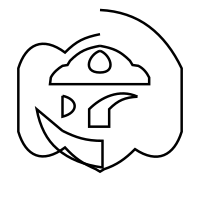

Generating Sample 2...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 4 4 . 4 L 12 . 4 4 . 4 C 12 . 6 4 . 5 12 . 9 4 . 6 13 . 2 4 . 7 L 15 . 9 7 . 6 L 18 . 6 10 . 4 C 18 . 7 11 . 0 18 . 7 11 . 7 18 . 7 12 . 3 L 15 . 0 16 . 2 L 11 . 3 20 . 1 C 9 . 4 21 . 1 8 . 5 20 . 0 9 . 2 18 . 2 L 12 . 3 15 . 0 L 15 . 5 11 . 8 L 11 . 9 8 . 1 L 8 . 4 4 . 5 C 7 . 8 3 . 3 8 . 7 2 . 4 10 . 0 3 . 2 L 12 . 9 7 . 0 L 15 . 8 4 . 1 C 16 . 2 4 . 0 16 . 5 3 . 9 16 . 8 3 . 8 L 16 . 8 3 . 8 " > < / path > < / svg >
post_processed: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><rect width="100%" height="100%" fill="white"/> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.4 4.4 L 12.4 4.4 C 12.6 4.5 1

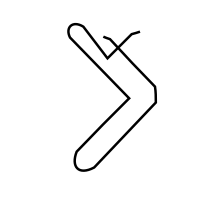

Generating Sample 3...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 3 . 2 L 12 . 0 3 . 2 C 14 . 0 3 . 5 15 . 6 3 . 9 17 . 0 5 . 5 C 18 . 4 7 . 2 18 . 9 9 . 4 18 . 7 11 . 5 C 18 . 4 13 . 6 17 . 3 15 . 6 15 . 4 16 . 9 C 14 . 0 17 . 9 12 . 7 18 . 2 11 . 5 18 . 1 C 10 . 2 18 . 0 9 . 0 17 . 4 7 . 7 16 . 7 L 4 . 2 18 . 4 L 5 . 6 15 . 1 C 4 . 5 12 . 9 4 . 3 10 . 8 4 . 8 9 . 0 C 5 . 3 7 . 2 6 . 6 5 . 6 8 . 4 4 . 5 C 10 . 1 3 . 5 12 . 2 3 . 2 14 . 5 3 . 5 L 14 . 5 3 . 5 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 8 . 0 L 12 . 0 8 . 0 C 13 . 7 8 . 3 15 . 0 8 . 7 15 . 7 10 . 4 C 16 . 3 11 . 7 16 . 1 13 . 1 15 . 3 14 . 2 C 14 . 6 15 . 3 13 . 4 16 . 0 12 . 0 16 . 0 C 10 . 6 16 

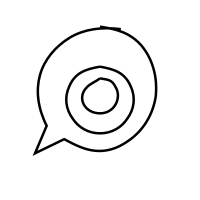

Generating Sample 4...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 2 . 6 L 12 . 0 2 . 6 C 13 . 6 2 . 7 15 . 1 3 . 1 16 . 4 3 . 7 C 17 . 8 4 . 4 18 . 9 5 . 4 19 . 9 6 . 8 C 21 . 2 8 . 8 21 . 6 11 . 1 21 . 3 13 . 3 C 21 . 0 15 . 5 19 . 9 17 . 5 18 . 2 19 . 0 C 16 . 6 20 . 5 14 . 5 21 . 5 12 . 0 21 . 5 C 9 . 5 21 . 5 7 . 4 20 . 5 5 . 7 19 . 0 C 4 . 1 17 . 5 3 . 0 15 . 5 2 . 7 13 . 3 C 2 . 4 11 . 1 2 . 8 8 . 8 4 . 1 6 . 8 C 5 . 1 5 . 4 6 . 2 4 . 4 7 . 6 3 . 7 C 8 . 9 3 . 1 10 . 4 2 . 7 12 . 0 2 . 6 L 12 . 0 2 . 6 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 5 . 2 L 12 . 0 5 . 2 C 14 . 4 5 . 6 16 . 5 6 . 3 17 . 8 8 . 6 C 19 . 1 10 . 8 18 . 9 13 . 3 17 . 8 15 . 3 C 16 . 

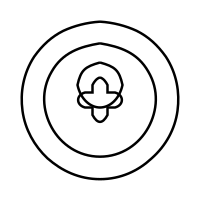

Generating Sample 5...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 3 . 9 L 12 . 0 3 . 9 C 13 . 6 4 . 1 15 . 2 4 . 5 16 . 5 5 . 3 C 17 . 8 6 . 1 18 . 8 7 . 3 19 . 5 8 . 9 C 19 . 9 9 . 8 20 . 4 11 . 5 19 . 7 12 . 4 C 19 . 4 12 . 7 18 . 9 12 . 6 18 . 5 12 . 5 L 18 . 5 12 . 5 C 17 . 8 10 . 2 16 . 6 8 . 5 14 . 9 7 . 4 C 13 . 3 6 . 4 11 . 3 6 . 0 9 . 0 6 . 4 L 9 . 0 6 . 4 C 9 . 8 5 . 5 10 . 9 5 . 0 12 . 0 4 . 6 L 12 . 0 4 . 6 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 6 . 9 L 12 . 0 6 . 9 C 14 . 0 7 . 5 15 . 5 8 . 5 16 . 1 9 . 9 C 16 . 7 11 . 3 16 . 4 13 . 1 15 . 3 15 . 0 L 14 . 9 14 . 5 C 15 . 4 13 . 0 15 . 6 11 . 5 15 . 2 10 . 3 C 14 . 8 9 . 1 13 . 8 8 . 1 12 . 0 8 .

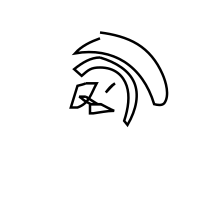

Generating Sample 6...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 1 . 9 L 12 . 0 1 . 9 C 13 . 7 2 . 0 15 . 3 2 . 4 16 . 7 3 . 1 C 18 . 1 3 . 8 19 . 4 4 . 8 20 . 4 6 . 3 C 21 . 9 8 . 5 22 . 3 11 . 0 22 . 0 13 . 4 C 21 . 6 15 . 7 20 . 4 17 . 9 18 . 7 19 . 5 C 16 . 9 21 . 1 14 . 6 22 . 1 12 . 0 22 . 1 C 9 . 4 22 . 1 7 . 1 21 . 1 5 . 3 19 . 5 C 3 . 6 17 . 9 2 . 4 15 . 7 2 . 0 13 . 4 C 1 . 7 11 . 0 2 . 1 8 . 5 3 . 6 6 . 3 C 4 . 6 4 . 8 5 . 9 3 . 8 7 . 3 3 . 1 C 8 . 7 2 . 4 10 . 3 2 . 0 12 . 0 1 . 9 L 12 . 0 1 . 9 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 11 . 7 7 . 3 L 11 . 7 7 . 3 C 12 . 0 7 . 3 12 . 2 7 . 3 12 . 5 7 . 3 L 16 . 3 11 . 0 C 16 . 3 11 . 4 16 . 3 11 . 7 16 . 

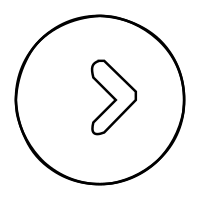

Generating Sample 7...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 11 . 6 1 . 4 L 11 . 6 1 . 4 C 11 . 9 1 . 4 12 . 1 1 . 4 12 . 4 1 . 4 L 17 . 5 4 . 6 L 22 . 5 7 . 9 C 22 . 6 8 . 1 22 . 7 8 . 4 22 . 7 8 . 6 L 22 . 7 15 . 4 C 22 . 7 15 . 7 22 . 6 15 . 9 22 . 5 16 . 1 L 17 . 5 19 . 4 L 12 . 4 22 . 6 C 12 . 2 22 . 6 11 . 9 22 . 6 11 . 6 22 . 6 L 6 . 5 19 . 4 L 1 . 5 16 . 1 C 1 . 4 15 . 9 1 . 3 15 . 7 1 . 3 15 . 4 L 1 . 3 8 . 6 C 1 . 3 8 . 4 1 . 4 8 . 1 1 . 5 7 . 9 L 6 . 5 4 . 6 L 11 . 6 1 . 4 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 10 . 9 3 . 1 L 10 . 9 7 . 3 L 7 . 2 9 . 6 L 3 . 5 7 . 3 L 7 . 7 4 . 0 L 10 . 9 1 . 7 " > < / path > < path fill = " none " stroke = " black " strok

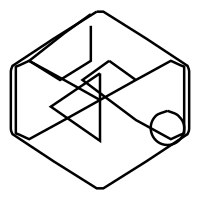

Generating Sample 8...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 1 . 2 L 12 . 0 1 . 2 C 12 . 2 1 . 4 12 . 4 1 . 6 12 . 7 1 . 8 L 12 . 7 7 . 0 L 12 . 7 12 . 3 C 12 . 4 12 . 6 12 . 3 13 . 1 12 . 0 13 . 1 C 11 . 7 13 . 1 11 . 6 12 . 6 11 . 3 12 . 3 L 11 . 3 7 . 0 L 11 . 3 1 . 8 C 11 . 5 1 . 6 11 . 8 1 . 4 12 . 0 1 . 2 L 12 . 0 1 . 2 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 7 1 . 2 L 12 . 7 1 . 2 C 12 . 9 1 . 4 13 . 1 1 . 6 13 . 4 1 . 8 L 13 . 4 7 . 0 L 13 . 4 12 . 3 C 13 . 1 12 . 6 12 . 9 13 . 1 12 . 7 13 . 1 C 12 . 4 13 . 1 12 . 2 12 . 6 12 . 0 12 . 3 L 12 . 0 7 . 0 L 12 . 0 1 . 8 C 12 . 2 1 . 6 12 . 5 1 . 4 12 . 7 1 . 2 L 12 . 7 1 . 2 " > < / path > < path fill 

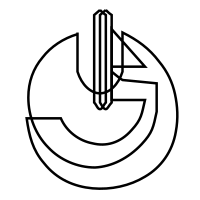

Generating Sample 9...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 1 . 2 1 . 2 L 8 . 4 1 . 2 L 15 . 6 1 . 2 L 22 . 8 1 . 2 L 22 . 8 8 . 4 L 22 . 8 15 . 6 L 22 . 8 22 . 8 L 15 . 6 22 . 8 L 8 . 4 22 . 8 L 1 . 2 22 . 8 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 12 . 0 3 . 0 L 12 . 0 3 . 0 C 13 . 5 3 . 2 14 . 9 3 . 5 16 . 2 4 . 1 C 17 . 5 4 . 7 18 . 6 5 . 6 19 . 5 7 . 0 C 20 . 8 8 . 9 21 . 2 11 . 1 20 . 9 13 . 2 C 20 . 5 15 . 3 19 . 5 17 . 2 18 . 0 18 . 7 C 16 . 4 20 . 1 14 . 4 21 . 0 12 . 0 21 . 0 C 9 . 6 21 . 0 7 . 6 20 . 1 6 . 0 18 . 7 C 4 . 5 17 . 2 3 . 5 15 . 3 3 . 1 13 . 2 C 2 . 8 11 . 1 3 . 2 8 . 9 4 . 5 7 . 0 C 5 . 4 5 . 6 6 . 5 4 . 7 7 . 8 4 . 1 C 9 . 1 3 . 5 10 . 5 3 . 2

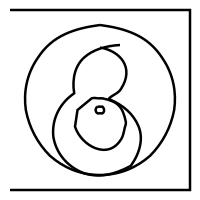

Generating Sample 10...
generated: < svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 11 . 1 5 . 7 L 11 . 1 5 . 7 C 11 . 7 5 . 4 12 . 3 5 . 0 12 . 9 5 . 0 C 14 . 1 5 . 0 14 . 7 6 . 8 13 . 8 7 . 5 C 12 . 8 8 . 2 11 . 4 7 . 5 11 . 2 6 . 4 C 11 . 1 6 . 0 11 . 7 5 . 8 11 . 9 5 . 7 L 11 . 9 5 . 7 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 11 . 9 8 . 9 L 11 . 9 8 . 9 C 12 . 1 9 . 0 12 . 2 9 . 0 12 . 3 9 . 1 L 12 . 3 13 . 5 L 16 . 1 13 . 5 C 16 . 2 13 . 6 16 . 2 13 . 9 16 . 1 14 . 0 L 12 . 0 14 . 0 L 7 . 9 14 . 0 C 7 . 8 13 . 9 7 . 8 13 . 6 7 . 9 13 . 5 L 11 . 4 13 . 5 L 11 . 4 9 . 1 C 11 . 6 9 . 0 11 . 7 8 . 9 11 . 9 8 . 9 L 11 . 9 8 . 9 " > < / path > < / svg >
post_processed: <svg xmlns="http://www

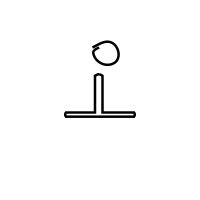

In [43]:
k = 10

print(f"\n--- Generating {k} Unconditional Samples ---")
unconditional_results = []

temperature = 0.7
temperature_str = f"{str(temperature)[0]}_{str(temperature)[2]}"

top_k = 5

for i in range(k):
    print(f"Generating Sample {i+1}...")
    sample = generate_svg(
        target_model,
        tokenizer,
        prompt="<svg",
        max_new_tokens=TOKEN_THRESHOLD,
        temperature=temperature,
        top_k=top_k
    )
    print(f"generated: {sample}")
    valid, rendered = evaluate_and_render(sample, f"xl_unconditional_{i}_t{temperature_str}_k{top_k}")
    unconditional_results.append((valid, rendered))

## Conditioned Samples


<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 5.7 L 16.3 5.7 C 17.5 6.0 18.1 5.9 18.8 7.1 C 19.9 9.1 18.5 11.6 16.3 11.6 C 14.0 11.6 12.6 9.1 13.7 7.1 C 14.4 5.9 15.1 6.0 16.3 5.7 L 16.3 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 5.7 L 16.3 5.7 C 17.5 6.0 18.1 5.9 18.8 7.1 C 19.9 9.1 18.5 11.6 16.3 11.6 C 14.0 11.6 12.6 9.1 13.7 7.1 C 14.4 5.9 15.1 6.0 16.3 5.7 L 16.3 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 6.6 L 16.3 6.6 C 16.8 6.8 17.3 6.8 17.7 7.2 C 19.0 8.4 18.0 10.6 16.3 10.6 C 14.5 10.6 13.6 8.4 14.8 7.2 C 15.2 6.8 15.8 6.8 16.3 6.6 L 16.3 6.6"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 10.9 12.0 L 13.4 12.0 C 15.3 12.5 16.1 13.7 17.3 15.2 L 19.0 15.3 C 20

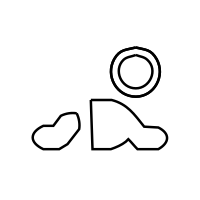

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 3.9 L 3.9 6.6 L 1.2 6.6 L 3.9 3.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 22.8 4.4 L 22.8 5.8 L 17.4 5.8 L 12.0 5.8 L 6.6 5.8 L 12.0 5.3 L 17.4 4.9 L 22.8 4.4"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 1.2 10.6 L 3.9 10.6 L 3.9 13.4 L 1.2 13.4"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 22.8 11.2 L 22.8 12.5 L 17.4 12.5 L 12.0 12.5 L 6.6 12.5 L 12.0 12.1 L 17.4 11.6 L 22.8 11.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 17.4 L 3.9 20.1 L 1.2 20.1 L 3.9 17.4"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 22.8 17.9 L 22.8 19.3 L 

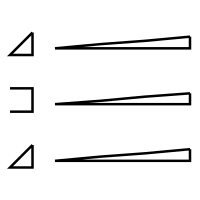

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 10.1 5.3 L 10.1 5.3 C 12.4 5.6 13.5 6.2 15.3 7.8 L 14.9 8.2 C 13.5 6.9 12.2 5.8 10.1 5.9 C 8.0 5.9 6.2 6.9 5.1 8.4 C 4.0 10.0 3.6 12.0 4.3 13.9 C 4.9 15.8 6.4 17.2 8.1 17.8 C 9.8 18.4 11.8 18.2 13.5 17.1 C 15.6 15.7 16.2 13.6 16.2 11.2 L 11.7 15.4 L 7.3 10.8 L 9.3 8.8 L 12.0 12.1 L 15.2 8.7 L 18.4 5.3 L 20.6 6.9 L 16.7 10.7 C 16.8 12.4 17.0 12.9 16.3 14.5 C 15.8 15.7 15.0 16.8 13.9 17.5 C 11.4 19.2 9.0 19.1 7.0 17.9 C 5.1 16.7 3.7 14.5 3.5 12.3 C 3.2 10.0 4.1 7.7 6.7 6.2 C 8.1 5.4 8.5 5.5 10.1 5.3 L 10.1 5.3"></path></svg>
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 10.1 5.3 L 10.1 5.3 C 12.4 5.6 13.5 6.2 15.3 7.8 L 14.9 8.2 C 13.5 6.9 12.2 5.8 10.1 5.9 C 8.0 5.9 

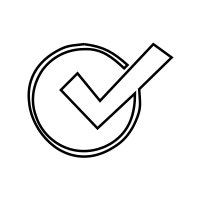

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.7 3.9 L 9.2 3.9 L 14.8 3.9 L 20.3 3.9 C 21.0 4.2 21.6 4.9 21.9 5.7 L 21.9 12.0 L 21.9 18.3 C 21.6 19.1 21.0 19.8 20.3 20.1 L 14.8 20.1 L 9.2 20.1 L 3.7 20.1 C 3.0 19.8 2.4 19.1 2.1 18.3 L 2.1 12.0 L 2.1 5.7 C 2.4 4.9 3.0 4.2 3.7 3.9 L 3.7 3.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 5.7 L 9.3 5.7 L 14.7 5.7 L 20.1 5.7 L 20.1 8.4 L 14.7 8.4 L 9.3 8.4 L 3.9 8.4 L 3.9 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 10.2 L 8.4 10.2 L 8.4 14.2 L 8.4 18.3 L 3.9 18.3 L 3.9 14.2 L 3.9 10.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 10.2 10.2 L 15.1 10.2 L 20.1 10.2 L 20.1 14.2 L 20.1 18.3 L 15.1 18.3 L 10.2 18.3 L 10.2 14.2 L 10.2 10.2"><

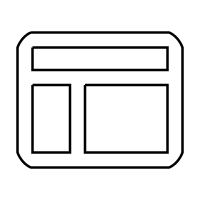

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.7 5.1 L 12.7 5.1 C 15.4 5.5 17.0 6.9 18.4 9.2 L 14.4 9.2 L 10.4 9.2 L 12.7 5.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.7 5.1 L 10.7 8.5 L 8.7 12.0 L 6.4 7.9 C 8.1 5.8 10.0 5.1 12.7 5.1 L 12.7 5.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 6.4 7.9 L 8.4 11.4 L 10.4 14.8 L 5.6 14.8 C 4.7 12.3 5.1 10.2 6.4 7.9 L 6.4 7.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 13.6 9.2 L 18.4 9.2 C 19.3 11.7 18.9 13.8 17.6 16.1 L 15.6 12.6 L 13.6 9.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 15.3 12.0 L 17.6 16.1 C 15.9 18.2 14.0 18.9 11.3 18.9 L 13.3 15.5 L 15.3 12.0"></path> <path fill="none" 

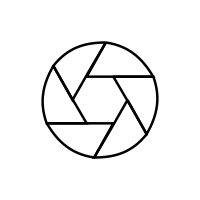

In [44]:
prefixes = []

ratio = 0.6

for i in range(5):
    svg_string = filtered_test["Svg"][i]
    print(svg_string)
    print(svg_string[: int(len(svg_string) * ratio)])

    evaluate_and_render(svg_string, f"sample_{i}")
    # display(SVG(post_process_svg(svg_string[:cap])))
    prefixes.append(svg_string[: int(len(svg_string) * ratio)])


--- Generating 5 Conditional Samples ---

Conditional 1 (Prompt: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 5.7 L 16.3 5.7 C 17.5 6.0 18.1 5.9 18.8 7.1 C 19.9 9.1 18.5 11.6 16.3 11.6 C 14.0 11.6 12.6 9.1 13.7 7.1 C 14.4 5.9 15.1 6.0 16.3 5.7 L 16.3 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 5.7 L 16.3 5.7 C 17.5 6.0 18.1 5.9 18.8 7.1 C 19.9 9.1 18.5 11.6 16.3 11.6 C 14.0 11.6 12.6 9.1 13.7 7.1 C 14.4 5.9 15.1 6.0 16.3 5.7 L 16.3 5.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 16.3 6.6 L 16.3 6.6 C 16.8 6.8 17.3 6.8 17.7 7.2 C 19.0 8.4 18.0 10.6 16.3 10.6 C 14.5 10.6 13.6 8.4 14.8 7.2 C 15.2 6.8 15.8 6.8 16.3 6.6 L 16.3 6.6"></path> <path fill="none" stroke...):
len(prefix): 865
< svg xmlns = " http : / / www . w3 . org / 20

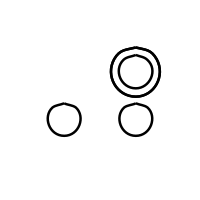


Conditional 2 (Prompt: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 3.9 L 3.9 6.6 L 1.2 6.6 L 3.9 3.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 22.8 4.4 L 22.8 5.8 L 17.4 5.8 L 12.0 5.8 L 6.6 5.8 L 12.0 5.3 L 17.4 4.9 L 22.8 4.4"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 1.2 10.6 L 3.9 10.6 L 3.9 13.4 L 1.2 13.4"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 22.8...):
len(prefix): 649
< svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 3 . 9 3 . 9 L 3 . 9 6 . 6 L 1 . 2 6 . 6 L 3 . 9 

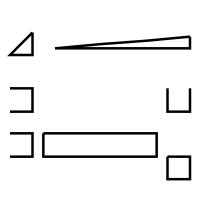


Conditional 3 (Prompt: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 10.1 5.3 L 10.1 5.3 C 12.4 5.6 13.5 6.2 15.3 7.8 L 14.9 8.2 C 13.5 6.9 12.2 5.8 10.1 5.9 C 8.0 5.9 6.2 6.9 5.1 8.4 C 4.0 10.0 3.6 12.0 4.3 13.9 C 4.9 15.8 6.4 17.2 8.1 17.8 C 9.8 18.4 11.8 18.2 13.5 17.1 C 15.6 15.7 16.2 13.6 16.2 11.2 L 11.7...):
len(prefix): 428
< svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 10 . 1 5 . 3 L 10 . 1 5 . 3 C 12 . 4 5 . 6 13 . 5 6 . 2 15 . 3 7 . 8 L 14 . 9 8 . 2 C 13 . 5 6 . 9 12 . 2 5 . 8 10 . 1 5 . 9 C 8 . 0 5 . 9 6 . 2 6 . 9 5 . 1 8 . 4 C 4 . 0 10 . 0 3 . 6 12 . 0 4 . 3 13 . 9 C 4 . 9 15 . 8 6 . 4 17 . 2 8 . 1 17 . 8 C 9 . 8 18 . 4 11 . 8 18

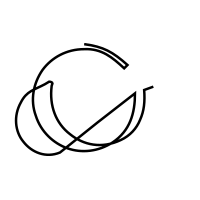


Conditional 4 (Prompt: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.7 3.9 L 9.2 3.9 L 14.8 3.9 L 20.3 3.9 C 21.0 4.2 21.6 4.9 21.9 5.7 L 21.9 12.0 L 21.9 18.3 C 21.6 19.1 21.0 19.8 20.3 20.1 L 14.8 20.1 L 9.2 20.1 L 3.7 20.1 C 3.0 19.8 2.4 19.1 2.1 18.3 L 2.1 12.0 L 2.1 5.7 C 2.4 4.9 3.0 4.2 3.7 3.9 L 3.7 3.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 3.9 5.7 L 9.3 5.7 L 14.7 5.7 L 20.1 5.7 L 20.1 8.4 L 14.7 8.4 L 9.3 8.4 L 3.9 ...):
len(prefix): 607
< svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 3 . 7 3 . 9 L 9 . 2 3 . 9 L 14 . 8 3 . 9 L 20 . 3 3 . 9 C 21 . 0 4 . 2 21 . 6 4 . 9 21 . 9

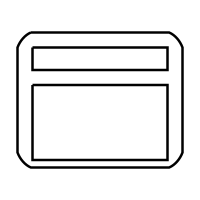


Conditional 5 (Prompt: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.7 5.1 L 12.7 5.1 C 15.4 5.5 17.0 6.9 18.4 9.2 L 14.4 9.2 L 10.4 9.2 L 12.7 5.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.7 5.1 L 10.7 8.5 L 8.7 12.0 L 6.4 7.9 C 8.1 5.8 10.0 5.1 12.7 5.1 L 12.7 5.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 6.4 7.9 L 8.4 11.4 L 10.4 14.8 L 5.6 14.8 C 4.7 12.3 5.1 10.2 6.4 7.9 L 6.4 7.9"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1...):
len(prefix): 701
< svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = 

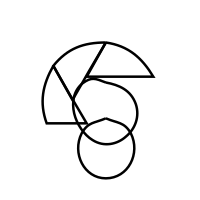

In [45]:
print("\n--- Generating 5 Conditional Samples ---")

conditional_results = []
for i, prefix in enumerate(prefixes):
    print(f"\nConditional {i+1} (Prompt: {prefix}...):")

    print(f"len(prefix): {len(prefix)}")
    sample = generate_svg(
        target_model,
        tokenizer,
        prompt=prefix,
        max_new_tokens=TOKEN_THRESHOLD,
        temperature=temperature,
        top_k=top_k,
    )
    print(sample)
    valid, rendered = evaluate_and_render(sample, f"conditional_{i}_t{temperature_str}_k{top_k}")
    conditional_results.append((valid, rendered))

Results


In [46]:
xml_valid_uncond = sum([1 for v, r in unconditional_results if v])
rendered_uncond = sum([1 for v, r in unconditional_results if r])

xml_valid_cond = sum([1 for v, r in conditional_results if v])
rendered_cond = sum([1 for v, r in conditional_results if r])

print(f"\n{'='*40}")
print(f"XL MODEL GENERATION SUMMARY")
print(f"{'='*40}")
print(f"Unconditional: {xml_valid_uncond}/10 Valid XML | {rendered_uncond}/10 Rendered")
print(f"Conditional:   {xml_valid_cond}/5 Valid XML | {rendered_cond}/5 Rendered")


XL MODEL GENERATION SUMMARY
Unconditional: 10/10 Valid XML | 10/10 Rendered
Conditional:   5/5 Valid XML | 5/5 Rendered


## Perplexity

In [47]:
import math
from torch.utils.data import TensorDataset, DataLoader

# 1. Prepare the test data (using your existing chunk_data function logic)
seq_len = target_model.block_size + 1
test_data = torch.tensor(test_input_ids, dtype=torch.long)

# Calculate how many full sequences we can make
num_chunks = len(test_data) // seq_len
test_data = test_data[: num_chunks * seq_len]
test_data_2d = test_data.view(num_chunks, seq_len)

# Split into inputs (X) and targets (Y)
X_test = test_data_2d[:, :-1]
Y_test = test_data_2d[:, 1:]

test_dataset = TensorDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=128)

# 2. Evaluate over the entire test set
target_model.eval()
total_loss = 0.0
total_batches = 0

print("Calculating Test Loss...")
with torch.inference_mode():
    for X, Y in tqdm(test_loader):
        X, Y = X.to(device), Y.to(device)
        _, loss = target_model(X, targets=Y)
        total_loss += loss.item()
        total_batches += 1 *(X.shape[0]/128)

# 3. Calculate metrics
avg_test_loss = total_loss / total_batches
test_perplexity = math.exp(avg_test_loss)

print(f"\n{'='*30}")
print(f"FINAL TEST METRICS (XL Model)")
print(f"{'='*30}")
print(f"Test Cross-Entropy Loss : {avg_test_loss:.4f}")
print(f"Test Perplexity         : {test_perplexity:.4f}")

Calculating Test Loss...


  0%|          | 0/40 [00:00<?, ?it/s]


FINAL TEST METRICS (XL Model)
Test Cross-Entropy Loss : 0.3883
Test Perplexity         : 1.4745
